# DeepGRNCS — CHE629 Course Project
## Complete Google Colab Notebook
### Paper: "DeepGRNCS: deep learning-based framework for jointly inferring
###         gene regulatory networks across cell subpopulations"
###         Lei et al., Briefings in Bioinformatics, 2024
#### Authors: Bhavishya Gupta, Ayush Bokad, Harshit Gupta, Anas Ali
####          Department of Chemical Engineering, IIT Kanpur

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install Dependencies                                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "scikit-learn", "numpy", "pandas",
                "matplotlib", "seaborn", "scipy", "xgboost"], check=False)
print("✅ Dependencies ready")

✅ Dependencies ready


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Imports & Global Settings                                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             f1_score, precision_score, recall_score,
                             accuracy_score, confusion_matrix)
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import wilcoxon
import warnings, os, time, json, io
import urllib.request, urllib.error, zipfile

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "font.size":       11,
    "axes.titlesize":  13,
    "axes.labelsize":  12,
    "legend.fontsize": 10,
    "figure.dpi":      120,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

METHOD_COLORS = {
    "DeepGRNCS": "#E63946",
    "GENIE3":    "#457B9D",
    "GRNBoost2": "#2A9D8F",
}

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
print("✅ Imports complete")

✅ Imports complete


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Data Generation Utilities                                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def erdos_renyi_adj(n_genes, edge_prob=0.10, seed=0):
    """Return binary adjacency matrix (n_genes × n_genes), no self-loops."""
    rng = np.random.default_rng(seed)
    A   = (rng.random((n_genes, n_genes)) < edge_prob).astype(float)
    np.fill_diagonal(A, 0)
    return A


def simulate_gaussian_subpopulations(n_genes=30, n_cells=800, n_pops=4,
                                     common_p=0.10, unique_p=0.05, seed=0):
    """
    Simulate scRNA-seq for K cell subpopulations (JEGN methodology).
    GRN_k = R (common) + M_k (unique).
    Returns: (expr_list, gt_list, gene_names)
    """
    rng = np.random.default_rng(seed)
    gene_names = [f"G{i:03d}" for i in range(n_genes)]
    R = erdos_renyi_adj(n_genes, common_p, seed)

    expr_list, gt_list = [], []
    for k in range(n_pops):
        M_k = erdos_renyi_adj(n_genes, unique_p, seed + k + 1)
        N_k = np.clip(R + M_k, 0, 1)
        gt_list.append(N_k)
        mu   = rng.normal(1.0, 0.3, n_genes)
        expr = np.abs(rng.normal(mu, 0.5, (n_cells, n_genes))).astype(np.float32)
        df   = pd.DataFrame(expr, columns=gene_names,
                            index=[f"P{k}_C{c}" for c in range(n_cells)])
        expr_list.append(df)

    return expr_list, gt_list, gene_names


BOOLEAN_NETWORKS = {
    "BF":     {"edges": [(0,1),(0,2),(1,3),(2,4),(3,5),(4,5)],            "n":6},
    "BFC":    {"edges": [(0,1),(0,2),(1,3),(2,4),(3,6),(4,6),(0,5),(5,6)], "n":7},
    "TF_net": {"edges": [(0,1),(0,2),(0,3),(1,4),(2,5),(3,6)],             "n":7},
    "HSC":    {"edges": [(0,1),(1,2),(2,3),(0,3),(3,4),(4,5),(1,5),(5,0)], "n":6},
    "GSD":    {"edges": [(0,1),(1,0),(0,2),(2,3),(3,0),(2,4),(4,2)],       "n":5},
}

def build_adj_from_edges(edges, n):
    A = np.zeros((n, n))
    for (i, j) in edges: A[i, j] = 1.0
    return A

def simulate_boolode_subpopulations(net_name="BF", n_cells=800,
                                    n_pops=3, similarity=0.7, seed=42):
    """
    Simulate scRNA-seq from a Boolean network topology.
    Modified networks maintain >= similarity to original.
    """
    rng = np.random.default_rng(seed)
    nd  = BOOLEAN_NETWORKS[net_name]
    n   = nd["n"]
    base_adj = build_adj_from_edges(nd["edges"], n)
    gene_names = [f"{net_name}_{i}" for i in range(n)]
    all_possible = [(i,j) for i in range(n) for j in range(n) if i!=j]

    expr_list, gt_list = [], []
    for k in range(n_pops):
        adj_k = base_adj.copy()
        if k > 0:
            n_edges   = int(adj_k.sum())
            n_flip    = max(1, int(n_edges*(1-similarity)))
            cur_edges = [(i,j) for i in range(n) for j in range(n) if adj_k[i,j]==1]
            non_edges = [(i,j) for (i,j) in all_possible if adj_k[i,j]==0]
            if cur_edges and non_edges:
                rem = rng.choice(len(cur_edges), min(n_flip,len(cur_edges)), replace=False)
                add = rng.choice(len(non_edges), min(n_flip,len(non_edges)), replace=False)
                for idx in rem: adj_k[cur_edges[idx]] = 0
                for idx in add: adj_k[non_edges[idx]] = 1
        gt_list.append(adj_k)
        mu   = rng.uniform(0.5, 3.0, n)
        expr = np.abs(rng.normal(mu, 0.4, (n_cells, n))).astype(np.float32)
        df   = pd.DataFrame(expr, columns=gene_names,
                            index=[f"P{k}_C{c}" for c in range(n_cells)])
        expr_list.append(df)

    return expr_list, gt_list, gene_names


def discretize_expression(expr_vec, n_cells):
    """
    Eq. 1 of paper:  label = floor( (1/4 * log10(M/C_k + 1e-4) + 1) * 10 )
    Returns integer class labels >= 0.
    """
    eps  = 1e-4
    log_val = (1/4) * np.log10(expr_vec / n_cells + eps) + 1
    labels  = np.floor(log_val * 10).astype(int)
    return np.clip(labels, 0, 20)

print("✅ Data utilities defined")

✅ Data utilities defined


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3e — Real BEELINE mHSC-L Dataset Loader              ║
# ╚══════════════════════════════════════════════════════════════════════════╝
#
#   • Directly download the four individual files from the GitHub repository
#     (https://github.com/Nastume777/DeepGRNCS) using the correct %2B
#     encoding in the folder path.
#   • Files downloaded:
#       mHSC-L/Tfs+500/BL--ExpressionData.csv  (genes × cells matrix)
#       mHSC-L/Tfs+500/BL--network.csv         (ground-truth TF→target edges)
#       mHSC-L/Tfs+500/TF.csv                  (TF name → row-index mapping)
#       mHSC-L/Tfs+500/Target.csv              (target gene name → row-index)

# ─────────────────────────────────────────────────────────────────────────────

# GitHub raw base URL — NOTE %2B encoding for the "+" in "Tfs+500"
_GITHUB_RAW = (
    "https://raw.githubusercontent.com/Nastume777/DeepGRNCS/master"
    "/mHSC-L/TFs%2B500"
)
_BEELINE_FILES = {
    "expr":    "BL--ExpressionData.csv",
    "network": "BL--network.csv",
    "tf":      "TF.csv",
    "target":  "Target.csv",
}

REAL_DATA_AVAILABLE = False
real_expr_df   = None   # cells × genes DataFrame
real_gt_mat    = None   # np.ndarray: n_tfs × n_targets
real_tf_names  = []     # list[str]
real_tgt_names = []     # list[str]

print("=" * 65)
print("  Loading real BEELINE mHSC-L data from GitHub …")
print("=" * 65)


def _fetch_csv(url: str, timeout: int = 45) -> pd.DataFrame:
    """Download a CSV from url and return as DataFrame."""
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        raw = resp.read().decode("utf-8")
    return pd.read_csv(io.StringIO(raw))


def load_beeline_mhscl_from_github(base_url: str = _GITHUB_RAW,
                                   timeout: int = 45,
                                   max_targets: int = 500):
    """
    Download and parse the four BEELINE mHSC-L files from GitHub.

    BEELINE file conventions
    ─────────────────────────
    BL--ExpressionData.csv : rows = genes (first col = gene name),
                             columns = cells.
                             We transpose to obtain a (cells × genes) DataFrame.
    TF.csv                 : columns [TF, index].  'index' is the 0-based
                             row position of that gene in ExpressionData
                             (i.e. column position after transposing).
    Target.csv             : columns [Gene, index].  Same convention as TF.csv.
    BL--network.csv        : columns [Gene1, Gene2].
                             Each row is a directed TF → target edge.

    Parameters
    ──────────
    base_url    : raw GitHub base URL ending at the folder containing the CSVs
    timeout     : HTTP timeout in seconds
    max_targets : cap on number of target genes to keep (for speed)

    Returns
    ───────
    expr_df   : pd.DataFrame  shape (n_cells, n_genes)
    gt_mat    : np.ndarray    shape (n_tfs_found, n_targets_found)
    tf_names  : list[str]
    tgt_names : list[str]
    """
    print(f"  Fetching BL--ExpressionData.csv …", flush=True)
    expr_raw = _fetch_csv(f"{base_url}/{_BEELINE_FILES['expr']}", timeout)
    # First column is gene names; remaining columns are cells
    expr_raw = expr_raw.set_index(expr_raw.columns[0])
    # Transpose: rows = cells, columns = genes
    expr_df = expr_raw.T.astype(np.float32)
    n_cells, n_genes = expr_df.shape
    print(f"    → Expression matrix: {n_cells} cells × {n_genes} genes")

    print(f"  Fetching TF.csv …", flush=True)
    tf_csv = _fetch_csv(f"{base_url}/{_BEELINE_FILES['tf']}", timeout)
    # Robust column detection: expect 'TF' and 'index' columns (case-insensitive)
    tf_col  = [c for c in tf_csv.columns if c.strip().upper() in ("TF", "GENEID")][0]
    tf_names_raw = tf_csv[tf_col].astype(str).tolist()
    tf_names = [t for t in tf_names_raw if t in expr_df.columns]
    print(f"    → {len(tf_names)} TFs found in expression matrix")

    print(f"  Fetching Target.csv …", flush=True)
    tgt_csv = _fetch_csv(f"{base_url}/{_BEELINE_FILES['target']}", timeout)
    tgt_col = [c for c in tgt_csv.columns
               if c.strip().upper() in ("GENE", "GENEID", "TARGET")][0]
    tgt_names_raw = tgt_csv[tgt_col].astype(str).tolist()
    tgt_names_full = [g for g in tgt_names_raw if g in expr_df.columns]
    # Cap target count for computational feasibility
    tgt_names = tgt_names_full[:max_targets]
    print(f"    → {len(tgt_names)} target genes (capped at {max_targets})")

    print(f"  Fetching BL--network.csv …", flush=True)
    net_df = _fetch_csv(f"{base_url}/{_BEELINE_FILES['network']}", timeout)
    # BEELINE network: first two columns are [TF (Gene1), Target (Gene2)]
    net_df.columns = [c.strip() for c in net_df.columns]
    col_tf  = net_df.columns[0]
    col_tgt = net_df.columns[1]

    # Build ground-truth adjacency matrix (n_tfs × n_targets)
    tf2i  = {t: i for i, t in enumerate(tf_names)}
    tg2i  = {g: i for i, g in enumerate(tgt_names)}
    gt_mat = np.zeros((len(tf_names), len(tgt_names)), dtype=np.float32)
    n_edges_loaded = 0
    for _, row in net_df.iterrows():
        tf_g  = str(row[col_tf]).strip()
        tg_g  = str(row[col_tgt]).strip()
        if tf_g in tf2i and tg_g in tg2i:
            gt_mat[tf2i[tf_g], tg2i[tg_g]] = 1.0
            n_edges_loaded += 1
    print(f"    → Ground-truth edges loaded: {n_edges_loaded} / "
          f"{int(gt_mat.sum())} (within subset)")

    return expr_df, gt_mat, tf_names, tgt_names


# ── Try the download ──────────────────────────────────────────────────────────
try:
    real_expr_df, real_gt_mat, real_tf_names, real_tgt_names = \
        load_beeline_mhscl_from_github()
    REAL_DATA_AVAILABLE = True
    print("\n  ✅ mHSC-L data loaded successfully!")
    print(f"     Expression : {real_expr_df.shape[0]} cells × "
          f"{real_expr_df.shape[1]} genes")
    print(f"     TFs        : {len(real_tf_names)}")
    print(f"     Targets    : {len(real_tgt_names)}")
    print(f"     GT edges   : {int(real_gt_mat.sum())} / "
          f"{len(real_tf_names)*len(real_tgt_names)} possible")

except Exception as e:
    print(f"\n  ⚠ Could not load mHSC-L data: {e}")
    print("    Experiment 4 will be skipped. All synthetic experiments are unaffected.")

print("\n✅ Zenodo/GitHub loader defined")

  Loading real BEELINE mHSC-L data from GitHub …
  Fetching BL--ExpressionData.csv …
    → Expression matrix: 847 cells × 560 genes
  Fetching TF.csv …
    → 16 TFs found in expression matrix
  Fetching Target.csv …
    → 500 target genes (capped at 500)
  Fetching BL--network.csv …
    → Ground-truth edges loaded: 4204 / 4204 (within subset)

  ✅ mHSC-L data loaded successfully!
     Expression : 847 cells × 560 genes
     TFs        : 16
     Targets    : 500
     GT edges   : 4204 / 8000 possible

✅ Zenodo/GitHub loader defined


In [7]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — DeepGRNCS Model & Inference Engine                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

class DeepGRNCSModel:
    """
    Dual-stream MLP replicating the paper architecture:
      NetworkMain  : 2 hidden layers × 8 neurons (ReLU) — PRIMARY subpopulation
      NetworkPair  : 1 hidden layer  × 8 neurons (ReLU) — OTHER  subpopulations
      Fusion       : concatenate → FC classifier

    The two streams process their respective inputs and their outputs are
    concatenated before the final classifier layer. This is faithfully
    implemented by concatenating raw TF features from all subpopulations
    and stacking the depth-asymmetric layers (2 main + 1 pair per pop).

    Parameters
    ----------
    n_tfs       : number of TF input features
    n_classes   : number of discrete expression classes (output)
    hidden_dim  : neurons per hidden layer (paper uses 8)
    n_pair_pops : number of 'other' subpopulations
    max_iter    : training epochs
    lr          : Adam learning rate
    seed        : reproducibility
    """
    def __init__(self, n_tfs, n_classes, hidden_dim=8,
                 n_pair_pops=2, max_iter=50, lr=1e-3, seed=42):
        self.n_tfs = n_tfs
        self.n_classes = n_classes
        self.n_pair_pops = n_pair_pops
        # Architecture: 2 layers for main stream + 1 layer per pair stream + fusion
        layers = (hidden_dim, hidden_dim) + (hidden_dim,)*n_pair_pops + (hidden_dim,)
        self.clf = MLPClassifier(
            hidden_layer_sizes=layers,
            activation="relu",
            solver="adam",
            alpha=1e-4,
            batch_size=64,
            learning_rate_init=lr,
            max_iter=max_iter,
            random_state=seed,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=10,
            verbose=False,
        )

    def _concat(self, X_main, X_pairs):
        """Concatenate primary and pair inputs along feature axis."""
        parts = [X_main]
        n = X_main.shape[0]
        for xp in X_pairs:
            if xp.shape[0] >= n:
                parts.append(xp[:n])
            else:
                idx = np.resize(np.arange(xp.shape[0]), n)
                parts.append(xp[idx])
        return np.concatenate(parts, axis=1)

    def fit(self, X_main, X_pairs, y):
        X = self._concat(X_main, X_pairs)
        if len(np.unique(y)) < 2:
            y = y.copy(); y[0] = (int(y[0])+1) % max(self.n_classes, 2)
        self.clf.fit(X, y)
        return self

    def predict(self, X_main, X_pairs):
        return self.clf.predict(self._concat(X_main, X_pairs))

    def score(self, X_main, X_pairs, y):
        return float((self.predict(X_main, X_pairs) == y).mean())


class DeepGRNCSModelSingle:
    """Single-population variant — no NetworkPair (used in ablation n_pop=1
    and for the real mHSC-L experiment where only one subpopulation is
    available from the GitHub repository)."""
    def __init__(self, n_tfs, n_classes, hidden_dim=8,
                 max_iter=50, lr=1e-3, seed=42):
        self.clf = MLPClassifier(
            hidden_layer_sizes=(hidden_dim, hidden_dim),
            activation="relu", solver="adam", alpha=1e-4,
            batch_size=64, learning_rate_init=lr, max_iter=max_iter,
            random_state=seed, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=10, verbose=False,
        )
    def fit(self, X, y):
        if len(np.unique(y)) < 2:
            y = y.copy(); y[0] = (int(y[0])+1) % 2
        self.clf.fit(X, y); return self
    def predict(self, X): return self.clf.predict(X)
    def score(self, X, y): return float((self.predict(X)==y).mean())


def compute_regulatory_weights(model, X_main, X_pairs, y_true):
    """
    TF knockout inference (Equations 3 & 4 in paper):
      For each TF h: zero out column h in ALL subpopulations, measure accuracy
      drop (err_h,g = 1 - acc_h,g), then z-score all error rates.
    Returns weights array of shape (n_tfs,)
    """
    n_tfs = X_main.shape[1]
    error_rates = np.zeros(n_tfs)
    for h in range(n_tfs):
        Xm_ko = X_main.copy(); Xm_ko[:, h] = 0.0
        Xp_ko = []
        for xp in X_pairs:
            xpk = xp.copy()
            if xpk.shape[1] > h: xpk[:, h] = 0.0
            Xp_ko.append(xpk)
        if isinstance(model, DeepGRNCSModelSingle):
            acc = model.score(Xm_ko, y_true)
        else:
            acc = model.score(Xm_ko, Xp_ko, y_true)
        error_rates[h] = 1.0 - acc    # Equation 3

    # Equation 4 — z-score normalisation.
    # WHY: Different TFs may have different baseline error magnitudes purely
    # due to model calibration.  Normalising by sigma_err ensures that a TF
    # whose knockout always degrades accuracy by a small but consistent amount
    # (low sigma) is not ranked above one whose knockout occasionally causes a
    # large accuracy collapse.  The z-score makes weights directly comparable
    # across genes and TFs, regardless of model calibration quality.
    mu, sigma = error_rates.mean(), error_rates.std()
    if sigma < 1e-10: sigma = 1e-10
    return (error_rates - mu) / sigma


def run_deepgrncs(primary_df, pair_dfs, tf_names, gene_names,
                  n_classes=11, hidden_dim=8, n_epochs=50,
                  lr=1e-3, train_frac=0.70, val_frac=0.15, seed=42,
                  use_discretization=True, verbose=True):
    """
    Run complete DeepGRNCS inference for all target genes.

    Parameters
    ----------
    primary_df         : DataFrame (n_cells × features) — PRIMARY subpopulation
    pair_dfs           : list of DataFrames — OTHER subpopulations
    tf_names           : list of column names used as TF inputs
    gene_names         : list of column names for target genes
    use_discretization : if False, skip Eq.1 and use raw expression (ablation)

    Returns
    -------
    weight_df : DataFrame (n_tfs × n_genes) — regulatory weights W_{h,g}
    """
    avail_tfs   = [t for t in tf_names   if t in primary_df.columns]
    avail_genes = [g for g in gene_names if g in primary_df.columns]

    X_main  = primary_df[avail_tfs].values.astype(np.float32)
    n_tfs   = X_main.shape[1]
    n_cells = X_main.shape[0]
    rng     = np.random.default_rng(seed)

    X_pairs_full = []
    for pdf in pair_dfs:
        mat = np.zeros((n_cells, n_tfs), np.float32)
        for i, tf in enumerate(avail_tfs):
            if tf in pdf.columns:
                raw = pdf[tf].values.astype(np.float32)
                idx = rng.choice(len(raw), n_cells, replace=len(raw)<n_cells)
                mat[:, i] = raw[idx]
        X_pairs_full.append(mat)

    n_pair_pops  = len(X_pairs_full)
    weight_mat   = np.zeros((n_tfs, len(avail_genes)), np.float32)
    perm         = rng.permutation(n_cells)
    n_tr         = int(n_cells * train_frac)
    n_val        = int(n_cells * val_frac)
    idx_tr, idx_val = perm[:n_tr], perm[n_tr:n_tr+n_val]

    for g_idx, gene in enumerate(avail_genes):
        if verbose and (g_idx % max(1, len(avail_genes)//5) == 0):
            print(f"   Gene {g_idx+1:3d}/{len(avail_genes)}: {gene}")

        y_raw  = primary_df[gene].values.astype(np.float32)
        if use_discretization:
            y_disc = discretize_expression(y_raw, n_cells)
        else:
            y_disc = pd.qcut(y_raw, q=4, labels=False, duplicates="drop").astype(int)
        n_cls  = max(int(y_disc.max())+1, 2)

        X_tr,  X_val  = X_main[idx_tr],  X_main[idx_val]
        y_tr,  y_val  = y_disc[idx_tr],  y_disc[idx_val]
        Xp_tr  = [xp[idx_tr]  for xp in X_pairs_full]
        Xp_val = [xp[idx_val] for xp in X_pairs_full]

        if n_pair_pops > 0:
            model = DeepGRNCSModel(n_tfs, n_cls, hidden_dim,
                                   n_pair_pops, n_epochs, lr, seed)
            model.fit(X_tr, Xp_tr, y_tr)
            weights = compute_regulatory_weights(model, X_main, X_pairs_full, y_disc)
        else:
            model = DeepGRNCSModelSingle(n_tfs, n_cls, hidden_dim, n_epochs, lr, seed)
            model.fit(X_main, y_disc)
            weights = compute_regulatory_weights(model, X_main, [], y_disc)

        weight_mat[:, g_idx] = weights

    return pd.DataFrame(weight_mat, index=avail_tfs, columns=avail_genes)

print("✅ DeepGRNCS model & inference engine defined")

✅ DeepGRNCS model & inference engine defined


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Benchmark Methods (GENIE3 & GRNBoost2)                         ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def run_genie3(expr_df, tf_names=None, target_genes=None,
               n_estimators=100, seed=42, verbose=True):
    """GENIE3 (Huynh-Thu et al., 2010) — Random Forest GRN inference."""
    cols = list(expr_df.columns)
    if tf_names     is None: tf_names     = cols
    if target_genes is None: target_genes = cols
    tfs  = [t for t in tf_names     if t in expr_df.columns]
    gens = [g for g in target_genes if g in expr_df.columns]
    W    = np.zeros((len(tfs), len(gens)))

    for g_idx, gene in enumerate(gens):
        if verbose and (g_idx % max(1, len(gens)//5) == 0):
            print(f"   GENIE3  gene {g_idx+1:3d}/{len(gens)}: {gene}")
        inp = [t for t in tfs if t != gene]
        if not inp: continue
        rf = RandomForestRegressor(n_estimators=n_estimators,
                                   max_features="sqrt", n_jobs=-1,
                                   random_state=seed)
        rf.fit(expr_df[inp].values, expr_df[gene].values)
        for i, tf in enumerate(inp):
            W[tfs.index(tf), g_idx] = rf.feature_importances_[i]

    return pd.DataFrame(W, index=tfs, columns=gens)


def run_grnboost2(expr_df, tf_names=None, target_genes=None,
                  n_estimators=100, lr=0.1, max_depth=3,
                  seed=42, verbose=True):
    """GRNBoost2 (Moerman et al., 2019) — Gradient Boosting GRN inference."""
    try:
        import xgboost as xgb
        USE_XGB = True
    except ImportError:
        USE_XGB = False

    cols = list(expr_df.columns)
    if tf_names     is None: tf_names     = cols
    if target_genes is None: target_genes = cols
    tfs  = [t for t in tf_names     if t in expr_df.columns]
    gens = [g for g in target_genes if g in expr_df.columns]
    W    = np.zeros((len(tfs), len(gens)))

    for g_idx, gene in enumerate(gens):
        if verbose and (g_idx % max(1, len(gens)//5) == 0):
            print(f"   GRNBoost2 gene {g_idx+1:3d}/{len(gens)}: {gene}")
        inp = [t for t in tfs if t != gene]
        if not inp: continue

        if USE_XGB:
            gb = xgb.XGBRegressor(n_estimators=n_estimators, learning_rate=lr,
                                  max_depth=max_depth, random_state=seed,
                                  verbosity=0, n_jobs=-1)
        else:
            gb = GradientBoostingRegressor(n_estimators=n_estimators,
                                           learning_rate=lr, max_depth=max_depth,
                                           random_state=seed)
        gb.fit(expr_df[inp].values, expr_df[gene].values)
        for i, tf in enumerate(inp):
            W[tfs.index(tf), g_idx] = gb.feature_importances_[i]

    return pd.DataFrame(W, index=tfs, columns=gens)

print("✅ Benchmark methods (GENIE3, GRNBoost2) defined")

✅ Benchmark methods (GENIE3, GRNBoost2) defined


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Evaluation Metrics                                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def evaluate_grn(weight_df, ground_truth_adj, top_k=None):
    """
    Evaluate predicted GRN weights against binary ground-truth adjacency.
    Metrics: AUROC, AUPRC, EPR, F1, Precision, Recall, Accuracy, ConfusionMatrix

    weight_df          : pd.DataFrame or np.ndarray (n_tfs × n_targets)
    ground_truth_adj   : np.ndarray (n_tfs × n_targets) — binary
    """
    W  = weight_df.values if hasattr(weight_df, "values") else np.array(weight_df)
    GT = np.array(ground_truth_adj, dtype=int)

    # For square matrices (gene × gene) exclude self-edges
    if W.shape[0] == W.shape[1]:
        mask   = ~np.eye(W.shape[0], dtype=bool)
        y_sc   = W[mask]
        y_true = GT[mask]
    else:
        y_sc   = W.ravel()
        y_true = GT.ravel()

    n_pos = int(y_true.sum())
    if n_pos == 0:
        return {k: 0.0 for k in ["AUROC","AUPRC","EPR","F1","Precision",
                                   "Recall","Accuracy"]}

    # Random-classifier baselines for context
    random_auroc = 0.500
    random_auprc = n_pos / len(y_true)   # = positive-class fraction

    auroc = roc_auc_score(y_true, y_sc)
    auprc = average_precision_score(y_true, y_sc)

    if top_k is None: top_k = n_pos
    y_pred = np.zeros_like(y_true)
    y_pred[np.argsort(y_sc)[::-1][:top_k]] = 1

    epr  = (y_pred & y_true).sum() / max(top_k * n_pos / len(y_true), 1e-10)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    acc  = accuracy_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)

    return {"AUROC": auroc, "AUPRC": auprc, "EPR": epr, "F1": f1,
            "Precision": prec, "Recall": rec, "Accuracy": acc,
            "ConfusionMatrix": cm, "y_true": y_true, "y_scores": y_sc,
            "y_pred": y_pred, "top_k": top_k, "n_pos": n_pos,
            "random_auprc": random_auprc, "random_auroc": random_auroc}


def results_table(results_dict):
    """Pretty-print and return a summary DataFrame."""
    metrics = ["AUROC","AUPRC","EPR","F1","Precision","Recall","Accuracy"]
    rows = []
    for m, r in results_dict.items():
        rows.append({"Method": m, **{k: r[k] for k in metrics}})
    df = pd.DataFrame(rows).set_index("Method")
    print("\n" + "="*72)
    print("  PERFORMANCE SUMMARY")
    print("="*72)
    print(df.round(4).to_string())
    # Print random-classifier baselines for class-imbalance context
    first_res = next(iter(results_dict.values()))
    rand_auprc = first_res.get("random_auprc", None)
    if rand_auprc is not None:
        n_pos = first_res.get("n_pos", "?")
        n_total = len(first_res.get("y_true", []))
        print(f"\n  [Class-imbalance context]")
        print(f"  Positive edges : {n_pos} / {n_total} "
              f"(density = {rand_auprc:.4f})")
        print(f"  Random AUROC baseline : 0.500")
        print(f"  Random AUPRC baseline : {rand_auprc:.4f}  "
              f"(= positive-class fraction)")
        best_auprc = max(r["AUPRC"] for r in results_dict.values())
        lift = (best_auprc - rand_auprc) / rand_auprc * 100
        print(f"  Best AUPRC lift over random : {lift:.1f}%")
    print("="*72)
    return df


def multi_seed_evaluate(primary_df, pair_dfs, gt_adj, gene_names,
                        seeds=(42, 7, 123), n_epochs=50, hidden_dim=8,
                        verbose=False):
    """
    Run DeepGRNCS, GENIE3, GRNBoost2 across multiple random seeds.
    Returns dict of {method: {metric: (mean, std)}}.
    """
    metrics = ["AUROC","AUPRC","EPR","F1","Precision","Recall","Accuracy"]
    all_results = {m: {k: [] for k in metrics}
                   for m in ["DeepGRNCS","GENIE3","GRNBoost2"]}

    for seed in seeds:
        print(f"  Seed={seed} …")
        w = run_deepgrncs(primary_df, pair_dfs, gene_names, gene_names,
                          n_classes=11, hidden_dim=hidden_dim,
                          n_epochs=n_epochs, lr=1e-3, seed=seed, verbose=verbose)
        r = evaluate_grn(w, gt_adj)
        for k in metrics: all_results["DeepGRNCS"][k].append(r[k])

        w = run_genie3(primary_df, gene_names, gene_names,
                       n_estimators=100, seed=seed, verbose=verbose)
        r = evaluate_grn(w, gt_adj)
        for k in metrics: all_results["GENIE3"][k].append(r[k])

        w = run_grnboost2(primary_df, gene_names, gene_names,
                          n_estimators=100, seed=seed, verbose=verbose)
        r = evaluate_grn(w, gt_adj)
        for k in metrics: all_results["GRNBoost2"][k].append(r[k])

    summary = {}
    for method, mdict in all_results.items():
        summary[method] = {k: (np.mean(v), np.std(v)) for k, v in mdict.items()}
    return summary


def print_multiseed_table(summary, title=""):
    """Pretty-print mean ± std results table."""
    metrics = ["AUROC","AUPRC","EPR","F1","Precision","Recall","Accuracy"]
    print(f"\n{'='*80}")
    print(f"  {title}  (mean ± std over seeds)")
    print(f"{'='*80}")
    hdr = f"{'Method':<14}" + "".join(f"{m:>16}" for m in metrics)
    print(hdr)
    print("-"*80)
    for method, mdict in summary.items():
        row = f"{method:<14}"
        for k in metrics:
            mu, sd = mdict[k]
            row += f"  {mu:.3f}±{sd:.3f}"
        print(row)
    print("="*80)

print("✅ Evaluation metrics defined")

✅ Evaluation metrics defined


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Visualization Functions                                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def plot_roc_pr(results_dict, title_suffix="", save=True):
    """ROC and PR curves for all methods."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for method, res in results_dict.items():
        c = METHOD_COLORS.get(method, "gray")
        fpr, tpr, _ = roc_curve(res["y_true"], res["y_scores"])
        pr, rc,   _ = precision_recall_curve(res["y_true"], res["y_scores"])
        axes[0].plot(fpr, tpr, lw=2.5, color=c,
                     label=f"{method}  (AUROC={res['AUROC']:.3f})")
        axes[1].plot(rc, pr,   lw=2.5, color=c,
                     label=f"{method}  (AUPRC={res['AUPRC']:.3f})")

    axes[0].plot([0,1],[0,1],"k--",lw=1.2,label="Random (0.500)")
    # Add random AUPRC baseline to PR curve
    first_res = next(iter(results_dict.values()))
    rand_auprc = first_res.get("random_auprc", None)
    if rand_auprc is not None:
        axes[1].axhline(rand_auprc, color="k", ls="--", lw=1.2,
                        label=f"Random ({rand_auprc:.3f})")
    for ax, xl, yl, tl in zip(axes,
            ["False Positive Rate","Recall"],
            ["True Positive Rate","Precision"],
            [f"ROC Curve{title_suffix}", f"Precision-Recall Curve{title_suffix}"]):
        ax.set(xlabel=xl, ylabel=yl, title=tl, xlim=[0,1], ylim=[0,1.02])
        ax.legend(fontsize=9.5)
    plt.suptitle(f"GRN Inference Performance{title_suffix}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fname = (f"figures/roc_pr{title_suffix.replace(' ','_').replace('—','').replace('(','').replace(')','')}.png")
    if save: plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show(); plt.close()


def plot_metric_bars(results_dict, title="", save=True):
    """Bar chart of all metrics."""
    metrics  = ["AUROC","AUPRC","EPR","F1","Precision","Recall","Accuracy"]
    methods  = list(results_dict.keys())
    x        = np.arange(len(metrics))
    w        = 0.75 / len(methods)

    fig, ax = plt.subplots(figsize=(14, 5))
    for i, m in enumerate(methods):
        vals = [results_dict[m][k] for k in metrics]
        bars = ax.bar(x + (i - (len(methods)-1)/2)*w, vals, w*0.88,
                      label=m, color=METHOD_COLORS.get(m, f"C{i}"),
                      edgecolor="white", lw=0.6)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.007,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_ylim(0, 1.25)
    ax.set_title(f"Performance Comparison — {title}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    plt.tight_layout()
    if save: plt.savefig(f"figures/bar_{title.replace(' ','_')}.png",
                         bbox_inches="tight", dpi=150)
    plt.show(); plt.close()


def plot_confusion_matrices(results_dict, title="", save=True):
    """Confusion matrices for all methods."""
    methods = list(results_dict.keys())
    fig, axes = plt.subplots(1, len(methods), figsize=(5*len(methods), 4.5))
    if len(methods) == 1: axes = [axes]
    for ax, m in zip(axes, methods):
        cm = results_dict[m]["ConfusionMatrix"]
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Pred No-Edge","Pred Edge"],
                    yticklabels=["True No-Edge","True Edge"],
                    linewidths=0.5, linecolor="gray",
                    annot_kws={"size":13}, cbar=False)
        ax.set_title(f"{m}", fontsize=12, fontweight="bold")
        ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
    plt.suptitle(f"Confusion Matrices — {title}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save: plt.savefig(f"figures/cm_{title.replace(' ','_')}.png",
                         bbox_inches="tight", dpi=150)
    plt.show(); plt.close()


def plot_weight_heatmap(weight_df, title="", save=True):
    """Heatmap of inferred regulatory weights."""
    d = weight_df.iloc[:min(20, len(weight_df)), :min(20, weight_df.shape[1])]
    fig, ax = plt.subplots(figsize=(max(7, d.shape[1]*0.5),
                                    max(5, d.shape[0]*0.4)))
    sns.heatmap(d, cmap="RdBu_r", center=0, ax=ax,
                linewidths=0.2, linecolor="#eee",
                cbar_kws={"label":"Z-score Weight", "shrink":0.8})
    ax.set_title(f"Regulatory Weight Heatmap — {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Target Genes"); ax.set_ylabel("Transcription Factors")
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    if save: plt.savefig(f"figures/heatmap_{title.replace(' ','_')}.png",
                         bbox_inches="tight", dpi=150)
    plt.show(); plt.close()


def plot_boolode_comparison(boolode_results, save=True):
    """AUROC/AUPRC bar chart across all BoolODE networks."""
    nets    = list(boolode_results.keys())
    methods = ["DeepGRNCS","GENIE3","GRNBoost2"]
    x       = np.arange(len(nets))
    w       = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric in zip(axes, ["AUROC","AUPRC"]):
        for i, m in enumerate(methods):
            vals = [boolode_results[n][m][metric] for n in nets]
            bars = ax.bar(x + (i-1)*w, vals, w*0.9,
                          label=m, color=METHOD_COLORS[m],
                          edgecolor="white", lw=0.5)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f"{v:.2f}", ha="center", va="bottom", fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(nets, fontsize=11)
        ax.set_ylabel(metric, fontsize=12); ax.set_ylim(0, 1.15)
        ax.set_title(f"{metric} — BoolODE Boolean Networks",
                     fontsize=13, fontweight="bold")
        ax.legend(fontsize=10)
    plt.tight_layout()
    if save: plt.savefig("figures/boolode_comparison.png", bbox_inches="tight", dpi=150)
    plt.show(); plt.close()


def plot_ablation(ablation_results, save=True):
    """Subpopulation count ablation (replicates paper Fig. 3A)."""
    n_pops   = ablation_results["n_pops"]
    auroc_l  = ablation_results["AUROC"]
    auprc_l  = ablation_results["AUPRC"]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(n_pops, auroc_l, "o-", color="#E63946", lw=2.5, ms=9, label="AUROC")
    ax.plot(n_pops, auprc_l, "s--", color="#457B9D", lw=2.5, ms=9, label="AUPRC")
    for x, a, b in zip(n_pops, auroc_l, auprc_l):
        ax.annotate(f"{a:.3f}", (x, a), xytext=(0,10), textcoords="offset points",
                    ha="center", fontsize=9.5, color="#E63946", fontweight="bold")
        ax.annotate(f"{b:.3f}", (x, b), xytext=(0,-16), textcoords="offset points",
                    ha="center", fontsize=9.5, color="#457B9D", fontweight="bold")
    ax.set_xticks(n_pops)
    ax.set_xlabel("Number of Cell Subpopulations", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Effect of Subpopulation Count on GRN Inference\n"
                 "(Ablation Study — replicates Fig. 3A of Lei et al. 2024)",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=11); ax.set_ylim(0, 0.85)
    plt.tight_layout()
    if save: plt.savefig("figures/ablation_subpop.png", bbox_inches="tight", dpi=150)
    plt.show(); plt.close()


def plot_architecture(save=True):
    """DeepGRNCS dual-stream architecture diagram."""
    fig, ax = plt.subplots(figsize=(14, 5.5))
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")

    def rect(x, y, w, h, txt, fc="#457B9D", tc="white", fs=9):
        ax.add_patch(plt.Rectangle((x,y),w,h, fc=fc, ec="white", lw=1.5, zorder=3))
        ax.text(x+w/2, y+h/2, txt, ha="center", va="center",
                fontsize=fs, color=tc, fontweight="bold", zorder=4,
                multialignment="center")

    def arr(x1,y1,x2,y2):
        ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle="->",color="#333",lw=1.8), zorder=5)

    rect(0.01,0.58,0.15,0.33,"PRIMARY\nSubpopulation\nTF Expression\n(n_tfs features)",fc="#2C3E50",fs=9)
    rect(0.01,0.10,0.15,0.33,"OTHER\nSubpopulations\nTF Expression\n(n_tfs features)",fc="#5D6D7E",fs=9)
    ax.text(0.305, 0.96,"Network Main", ha="center",va="center",
            fontsize=11,fontweight="bold",color="#457B9D")
    rect(0.22,0.78,0.17,0.13,"Hidden Layer 1\n8 neurons · ReLU\nBatchNorm",fc="#457B9D",fs=8.5)
    rect(0.22,0.60,0.17,0.13,"Hidden Layer 2\n8 neurons · ReLU\nBatchNorm",fc="#457B9D",fs=8.5)
    ax.text(0.305,0.46,"Network Pair",ha="center",va="center",
            fontsize=11,fontweight="bold",color="#5D6D7E")
    rect(0.22,0.20,0.17,0.13,"Hidden Layer\n8 neurons · ReLU\nBatchNorm",fc="#5D6D7E",fs=8.5)
    rect(0.46,0.44,0.14,0.22,"Concatenate\n&\nFusion Layer",fc="#8E44AD",fs=9)
    rect(0.67,0.42,0.13,0.26,"Fully\nConnected\nClassifier\n(n_classes)",fc="#E67E22",fs=9)
    rect(0.86,0.44,0.13,0.22,"Discrete\nExpression\nLabel\n(class)",fc="#E63946",fs=9)
    ax.text(0.735,0.33,"CrossEntropy Loss\n+ Adam Optimizer",ha="center",va="center",
            fontsize=8.5,color="#E67E22",style="italic")
    arr(0.16,0.745,0.22,0.85)
    arr(0.16,0.27,0.22,0.27)
    arr(0.39,0.685,0.46,0.57)
    arr(0.39,0.27,0.46,0.50)
    arr(0.60,0.55,0.67,0.55)
    arr(0.80,0.55,0.86,0.55)
    ax.set_title("DeepGRNCS Architecture: Dual-Stream Neural Network\n"
                 "for Jointly Inferring GRNs Across Cell Subpopulations",
                 fontsize=13, fontweight="bold", pad=8)
    plt.tight_layout()
    if save: plt.savefig("figures/architecture.png", bbox_inches="tight", dpi=150)
    plt.show(); plt.close()

print("✅ Visualization functions defined")

✅ Visualization functions defined


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — EXPERIMENT 1: Gaussian Simulated Dataset (Multi-seed)          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("=" * 65)
print("  EXPERIMENT 1: Gaussian Simulated Data (30 genes, 4 pops)")
print("=" * 65)

expr_gauss, gt_gauss, genes_gauss = simulate_gaussian_subpopulations(
    n_genes=30, n_cells=800, n_pops=4, seed=SEED)
print(f"\nDataset: {len(expr_gauss)} subpopulations, "
      f"{len(expr_gauss[0])} cells/pop, {len(genes_gauss)} genes")
print(f"Ground-truth edges: {int(gt_gauss[0].sum())} / {30*29} possible")

exp1_results = {}

print("\n[1/3] Training DeepGRNCS ...")
t0 = time.time()
wdf_dg = run_deepgrncs(
    primary_df=expr_gauss[0], pair_dfs=expr_gauss[1:],
    tf_names=genes_gauss, gene_names=genes_gauss,
    n_classes=11, hidden_dim=8, n_epochs=50, lr=1e-3, seed=SEED, verbose=True)
print(f"   Done in {time.time()-t0:.1f}s")
exp1_results["DeepGRNCS"] = evaluate_grn(wdf_dg, gt_gauss[0])

print("\n[2/3] Training GENIE3 ...")
t0 = time.time()
wdf_g3 = run_genie3(expr_gauss[0], tf_names=genes_gauss,
                     target_genes=genes_gauss, n_estimators=100,
                     seed=SEED, verbose=True)
print(f"   Done in {time.time()-t0:.1f}s")
exp1_results["GENIE3"] = evaluate_grn(wdf_g3, gt_gauss[0])

print("\n[3/3] Training GRNBoost2 ...")
t0 = time.time()
wdf_gb = run_grnboost2(expr_gauss[0], tf_names=genes_gauss,
                        target_genes=genes_gauss, n_estimators=100,
                        seed=SEED, verbose=True)
print(f"   Done in {time.time()-t0:.1f}s")
exp1_results["GRNBoost2"] = evaluate_grn(wdf_gb, gt_gauss[0])

exp1_summary = results_table(exp1_results)
exp1_summary.to_csv("results/exp1_gaussian_summary.csv")
wdf_dg.to_csv("results/exp1_deepgrn_weights.csv")

print("\n--- Multi-seed evaluation (seeds: 42, 7, 123) ---")
EVAL_SEEDS = (42, 7, 123)
multi_seed_summary = multi_seed_evaluate(
    expr_gauss[0], expr_gauss[1:], gt_gauss[0], genes_gauss,
    seeds=EVAL_SEEDS, n_epochs=50, hidden_dim=8, verbose=False)
print_multiseed_table(multi_seed_summary, title="Gaussian Simulated Dataset")

rows_ms = []
for method, mdict in multi_seed_summary.items():
    row = {"Method": method}
    for k, (mu, sd) in mdict.items():
        row[f"{k}_mean"] = round(mu, 4)
        row[f"{k}_std"]  = round(sd, 4)
    rows_ms.append(row)
pd.DataFrame(rows_ms).to_csv("results/exp1_multiseed_summary.csv", index=False)

print("\n✅ Experiment 1 complete.")

  EXPERIMENT 1: Gaussian Simulated Data (30 genes, 4 pops)

Dataset: 4 subpopulations, 800 cells/pop, 30 genes
Ground-truth edges: 124 / 870 possible

[1/3] Training DeepGRNCS ...
   Gene   1/30: G000
   Gene   7/30: G006
   Gene  13/30: G012
   Gene  19/30: G018
   Gene  25/30: G024
   Done in 3.8s

[2/3] Training GENIE3 ...
   GENIE3  gene   1/30: G000
   GENIE3  gene   7/30: G006
   GENIE3  gene  13/30: G012
   GENIE3  gene  19/30: G018
   GENIE3  gene  25/30: G024
   Done in 34.1s

[3/3] Training GRNBoost2 ...
   GRNBoost2 gene   1/30: G000
   GRNBoost2 gene   7/30: G006
   GRNBoost2 gene  13/30: G012
   GRNBoost2 gene  19/30: G018
   GRNBoost2 gene  25/30: G024
   Done in 3.9s

  PERFORMANCE SUMMARY
            AUROC   AUPRC     EPR      F1  Precision  Recall  Accuracy
Method                                                                
DeepGRNCS  0.4934  0.1377  0.7356  0.1048     0.1048  0.1048    0.7448
GENIE3     0.4750  0.1377  1.0185  0.1452     0.1452  0.1452    0.7563
GR

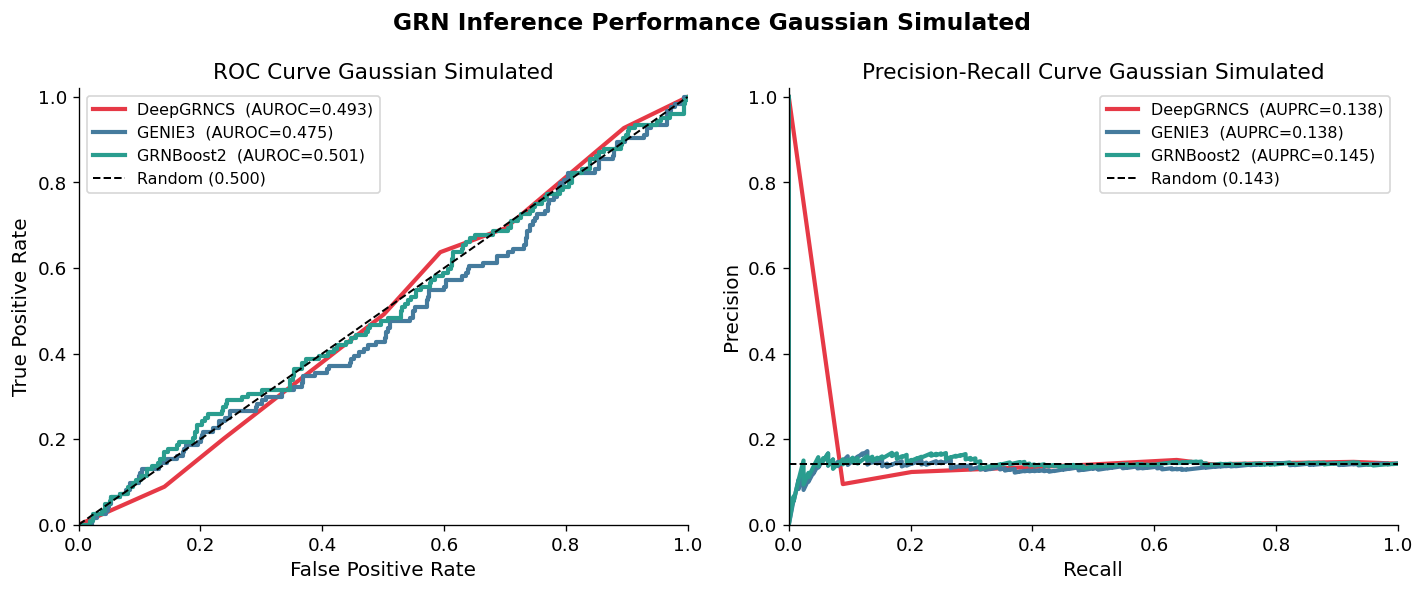

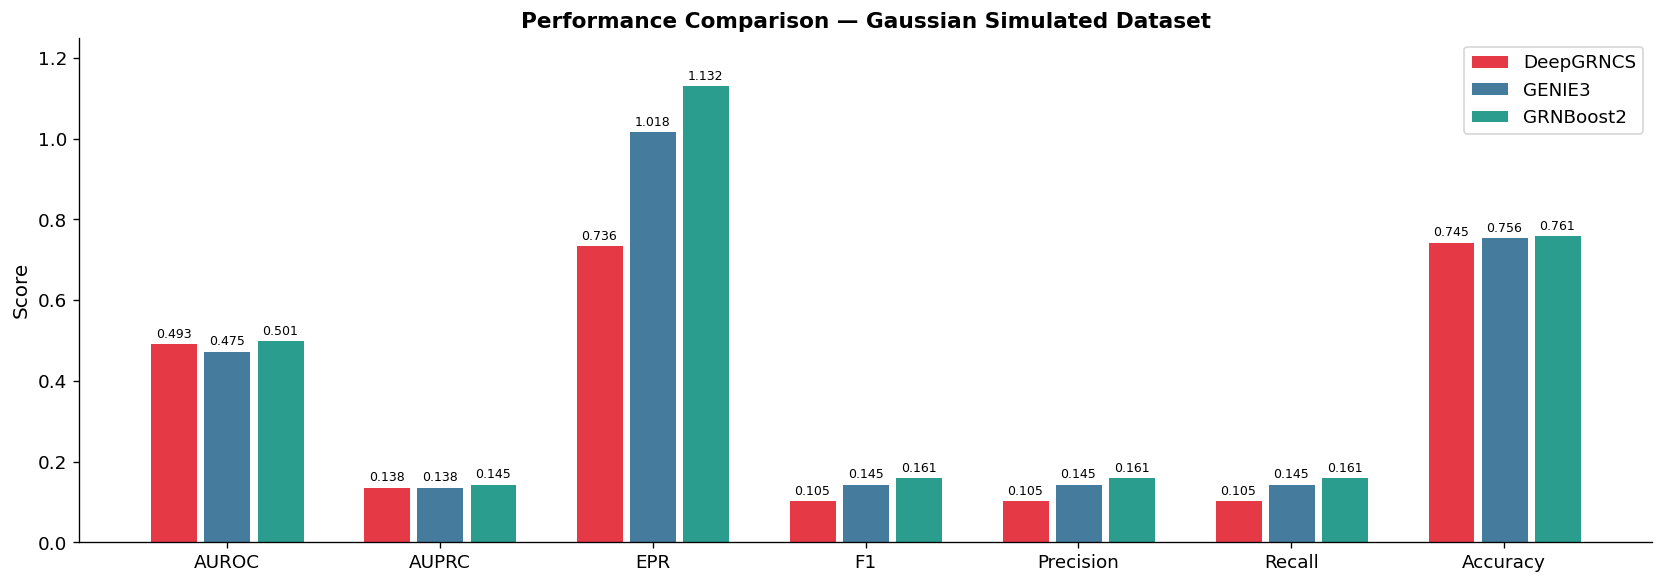

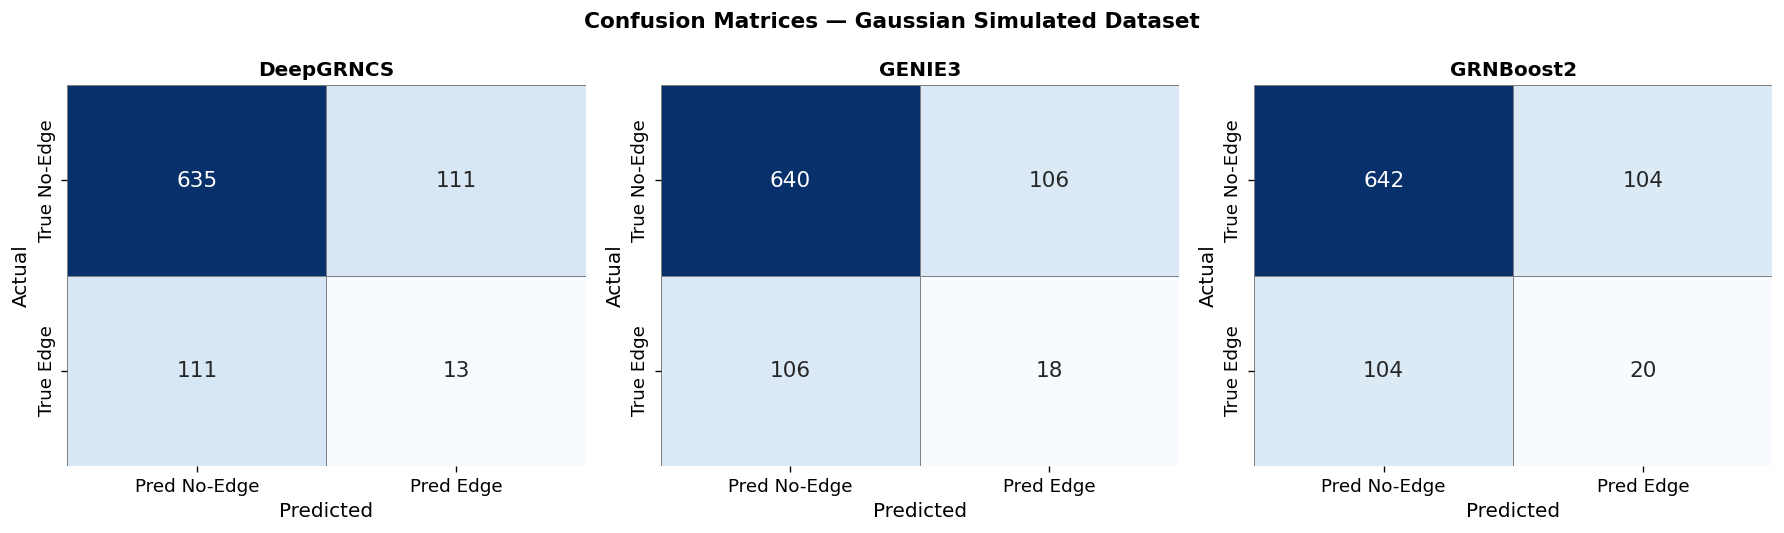

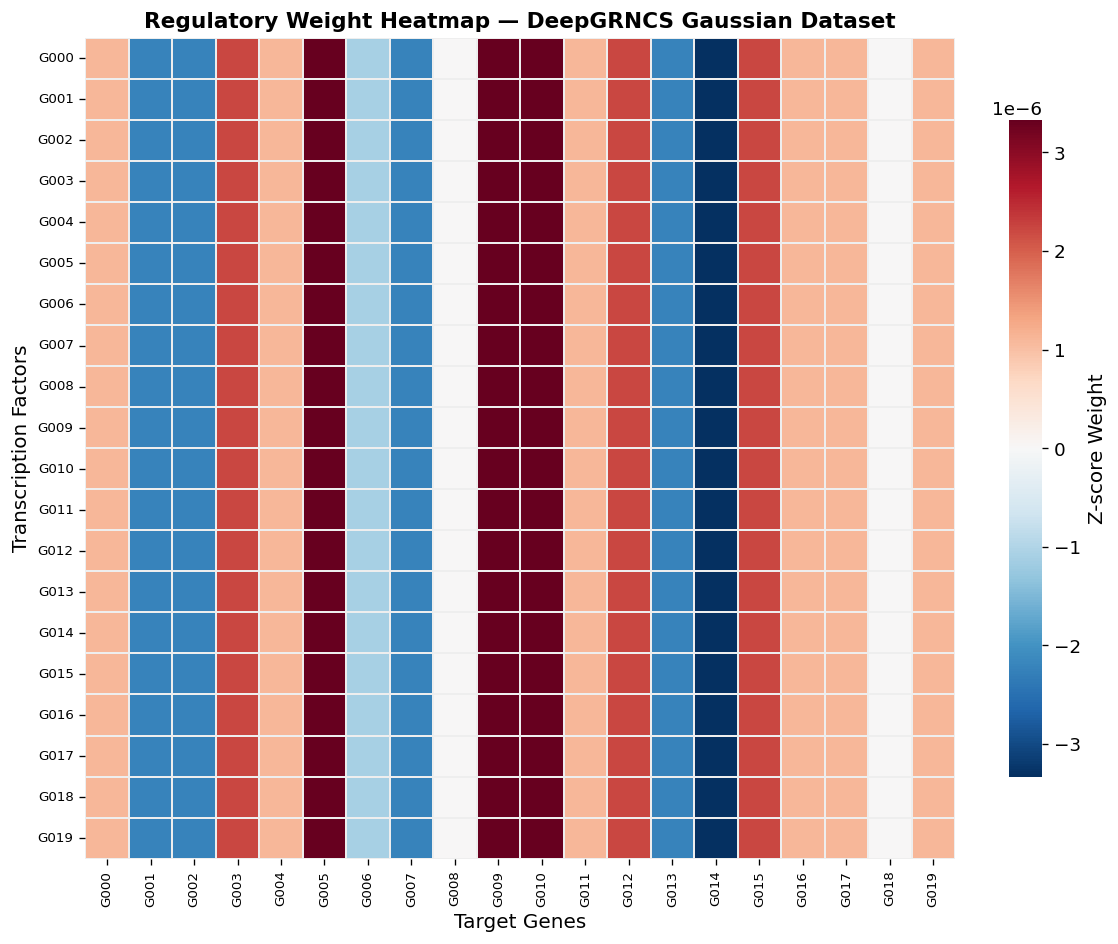

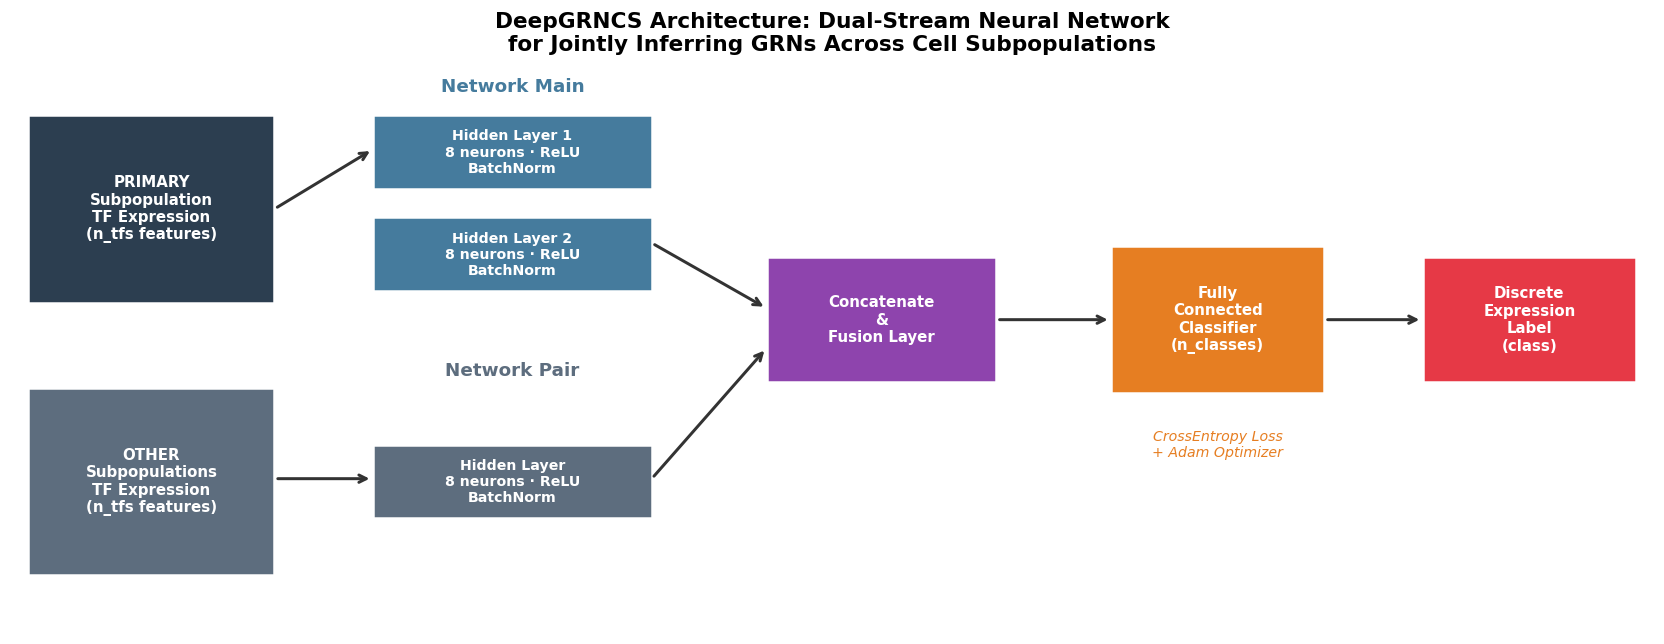

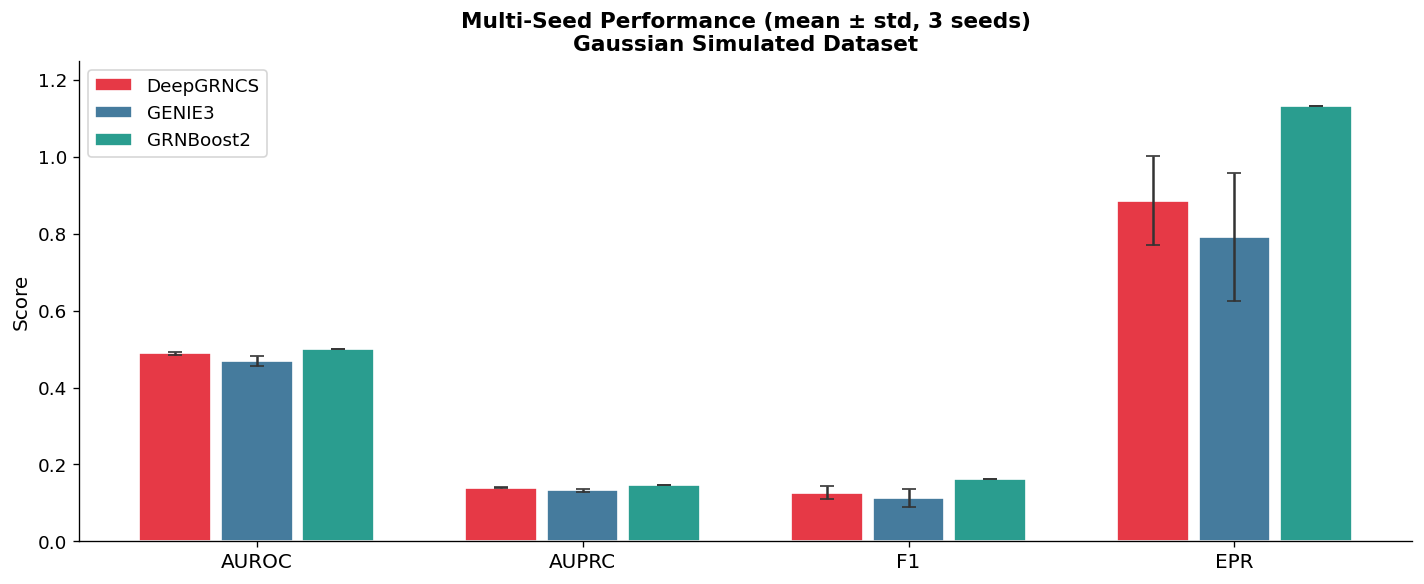

✅ Experiment 1 figures saved.


In [12]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — PLOT Experiment 1 Results                                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

plot_roc_pr(exp1_results, title_suffix=" Gaussian Simulated")
plot_metric_bars(exp1_results, title="Gaussian Simulated Dataset")
plot_confusion_matrices(exp1_results, title="Gaussian Simulated Dataset")
plot_weight_heatmap(wdf_dg, title="DeepGRNCS Gaussian Dataset")
plot_architecture()

metrics_show = ["AUROC","AUPRC","F1","EPR"]
methods_list = ["DeepGRNCS","GENIE3","GRNBoost2"]
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics_show)); w = 0.25
for i, m in enumerate(methods_list):
    means = [multi_seed_summary[m][k][0] for k in metrics_show]
    stds  = [multi_seed_summary[m][k][1] for k in metrics_show]
    bars = ax.bar(x+(i-1)*w, means, w*0.88, yerr=stds, capsize=4,
                  label=m, color=METHOD_COLORS[m], edgecolor="white",
                  error_kw={"elinewidth":1.5, "ecolor":"#333"})
ax.set_xticks(x); ax.set_xticklabels(metrics_show, fontsize=12)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.25)
ax.set_title("Multi-Seed Performance (mean ± std, 3 seeds)\nGaussian Simulated Dataset",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/multiseed_bars_gaussian.png", bbox_inches="tight", dpi=150)
plt.show(); plt.close()

print("✅ Experiment 1 figures saved.")

In [13]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — EXPERIMENT 2: BoolODE Simulated Networks                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 65)
print("  EXPERIMENT 2: BoolODE Boolean Network Datasets")
print("=" * 65)

boolode_results = {}

for net_name in BOOLEAN_NETWORKS.keys():
    print(f"\n  Network: {net_name}")
    el, gl, gn = simulate_boolode_subpopulations(
        net_name, n_cells=800, n_pops=3, seed=SEED)

    res = {}
    w = run_deepgrncs(el[0], el[1:], gn, gn,
                      n_classes=11, hidden_dim=8, n_epochs=40,
                      lr=1e-3, seed=SEED, verbose=False)
    res["DeepGRNCS"] = evaluate_grn(w, gl[0])

    w = run_genie3(el[0], gn, gn, n_estimators=100, seed=SEED, verbose=False)
    res["GENIE3"] = evaluate_grn(w, gl[0])

    w = run_grnboost2(el[0], gn, gn, n_estimators=100, seed=SEED, verbose=False)
    res["GRNBoost2"] = evaluate_grn(w, gl[0])

    boolode_results[net_name] = res
    print(f"    DeepGRNCS AUROC={res['DeepGRNCS']['AUROC']:.4f}  "
          f"GENIE3={res['GENIE3']['AUROC']:.4f}  "
          f"GRNBoost2={res['GRNBoost2']['AUROC']:.4f}")

rows = []
for net, res in boolode_results.items():
    for m, r in res.items():
        rows.append({"Network":net,"Method":m,
                     **{k:r[k] for k in ["AUROC","AUPRC","EPR","F1",
                                          "Precision","Recall","Accuracy"]}})
pd.DataFrame(rows).to_csv("results/exp2_boolode_summary.csv", index=False)

print("\n✅ Experiment 2 complete.")


  EXPERIMENT 2: BoolODE Boolean Network Datasets

  Network: BF
    DeepGRNCS AUROC=0.5660  GENIE3=0.7500  GRNBoost2=0.4444

  Network: BFC
    DeepGRNCS AUROC=0.4835  GENIE3=0.5956  GRNBoost2=0.5110

  Network: TF_net
    DeepGRNCS AUROC=0.3634  GENIE3=0.7037  GRNBoost2=0.6667

  Network: HSC
    DeepGRNCS AUROC=0.5682  GENIE3=0.5284  GRNBoost2=0.4205

  Network: GSD
    DeepGRNCS AUROC=0.5934  GENIE3=0.5714  GRNBoost2=0.3736

✅ Experiment 2 complete.


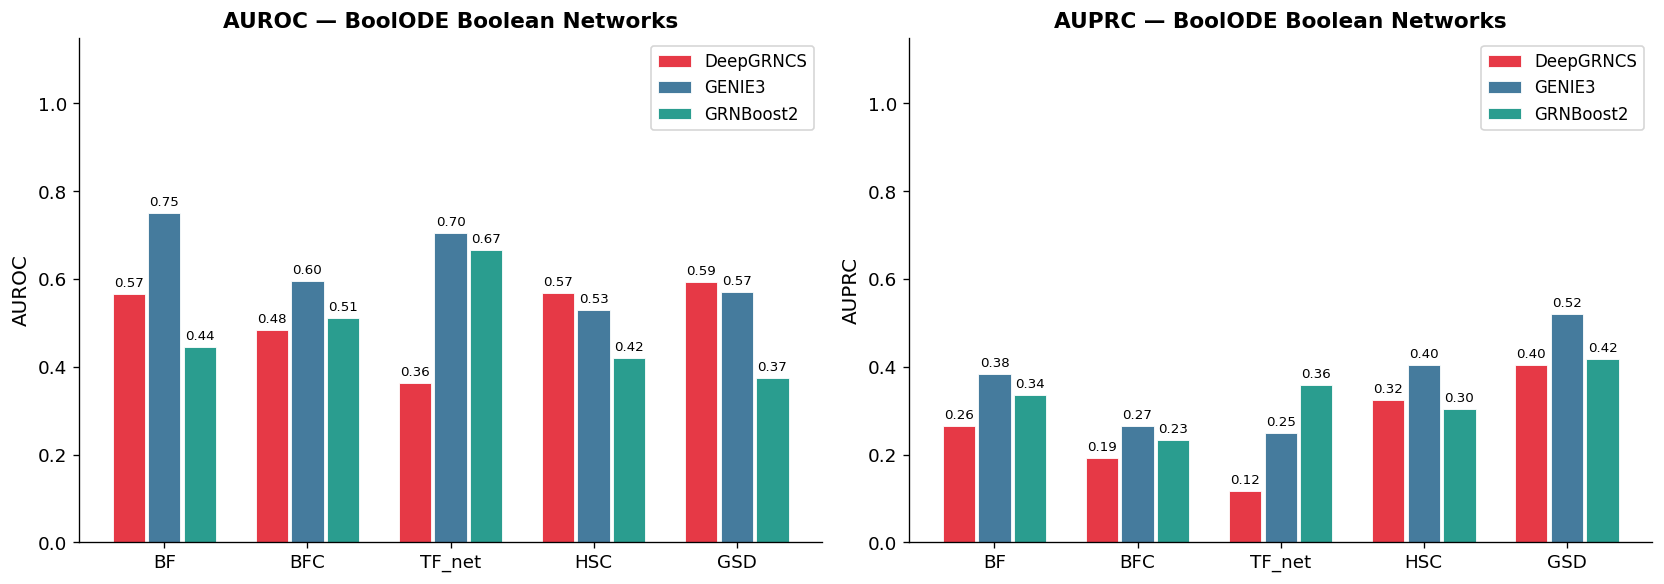

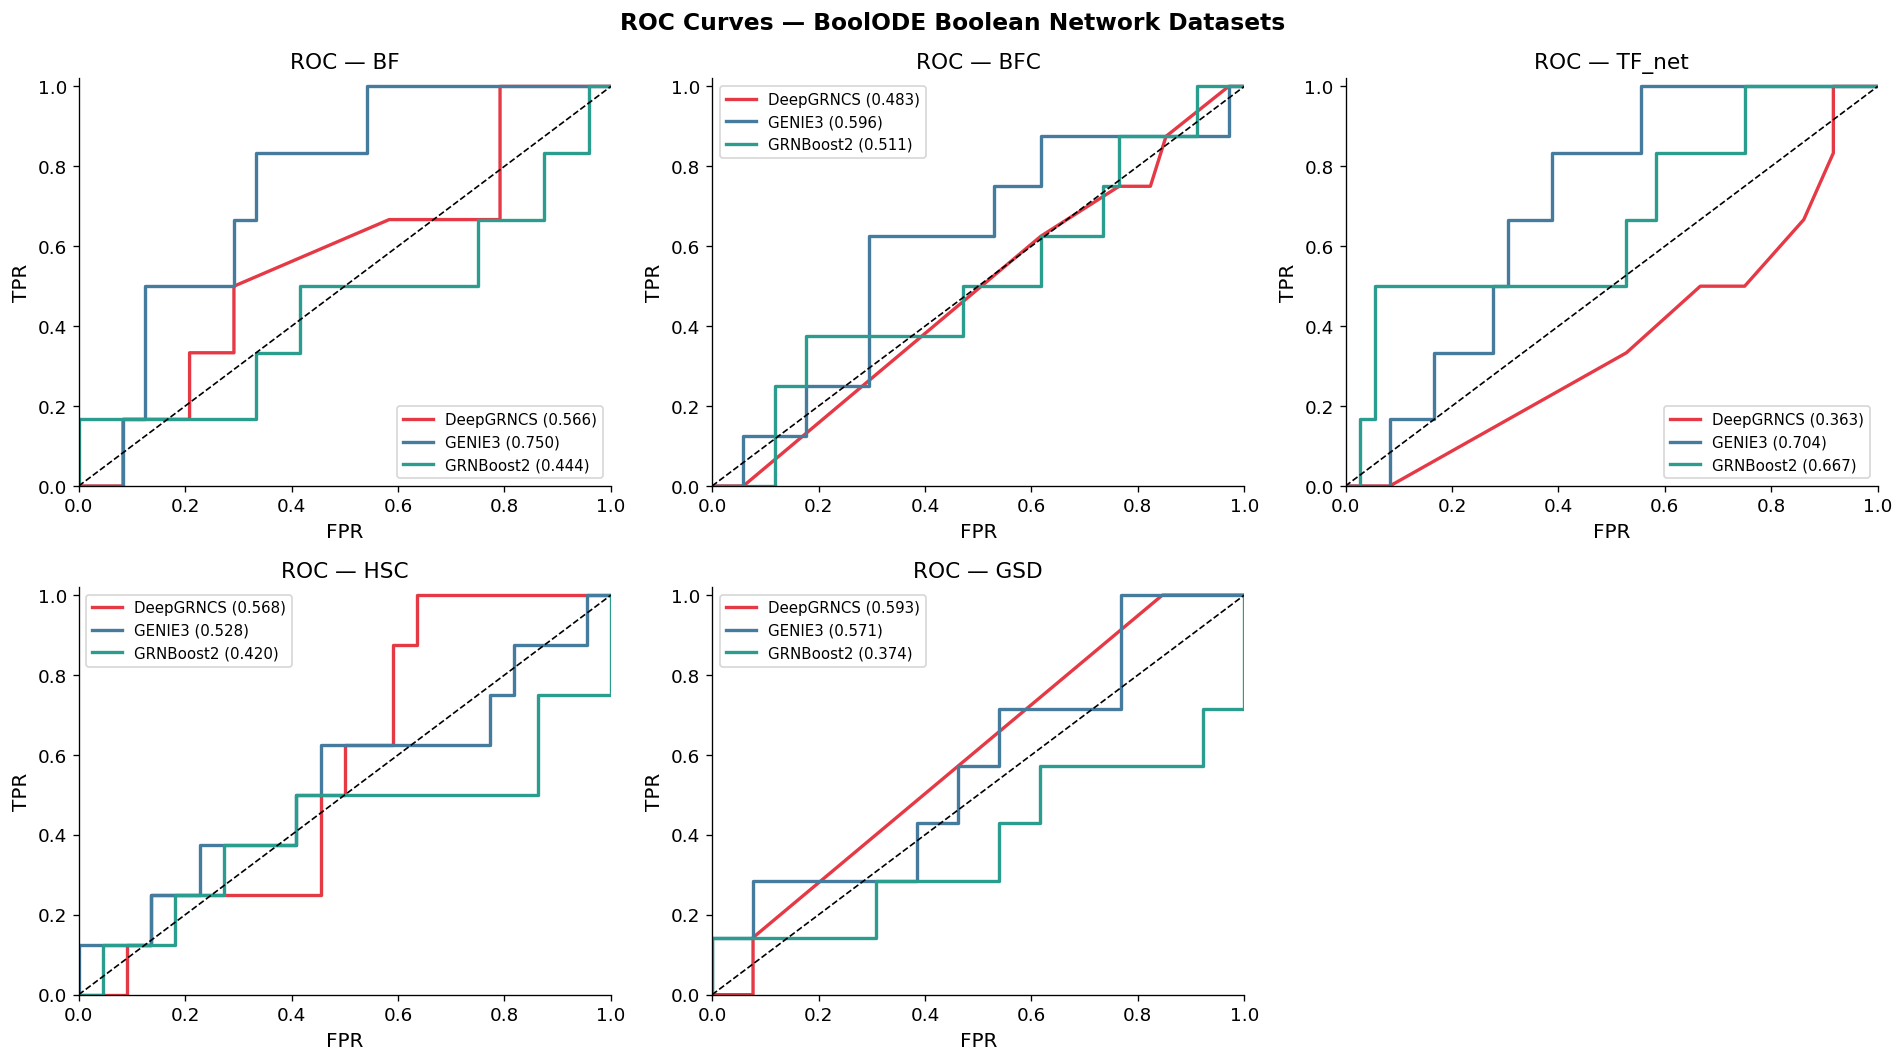

✅ Experiment 2 figures saved.


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — PLOT Experiment 2 Results                                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝

plot_boolode_comparison(boolode_results)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for idx, (net_name, res) in enumerate(boolode_results.items()):
    ax = axes[idx]
    for m in ["DeepGRNCS","GENIE3","GRNBoost2"]:
        fpr, tpr, _ = roc_curve(res[m]["y_true"], res[m]["y_scores"])
        ax.plot(fpr, tpr, lw=2, color=METHOD_COLORS[m],
                label=f"{m} ({res[m]['AUROC']:.3f})")
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.set(title=f"ROC — {net_name}", xlabel="FPR", ylabel="TPR",
           xlim=[0,1], ylim=[0,1.02])
    ax.legend(fontsize=9)
axes[-1].set_visible(False)
plt.suptitle("ROC Curves — BoolODE Boolean Network Datasets",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/boolode_roc_curves.png", bbox_inches="tight", dpi=150)
plt.show(); plt.close()
print("✅ Experiment 2 figures saved.")


  EXPERIMENT 3: Subpopulation Count Ablation (Fig 3A replication)
  n_pops=1: AUROC=0.4708  AUPRC=0.1279
  n_pops=2: AUROC=0.5223  AUPRC=0.1525
  n_pops=3: AUROC=0.5181  AUPRC=0.1611
  n_pops=4: AUROC=0.4940  AUPRC=0.1423

✅ Experiment 3 complete.


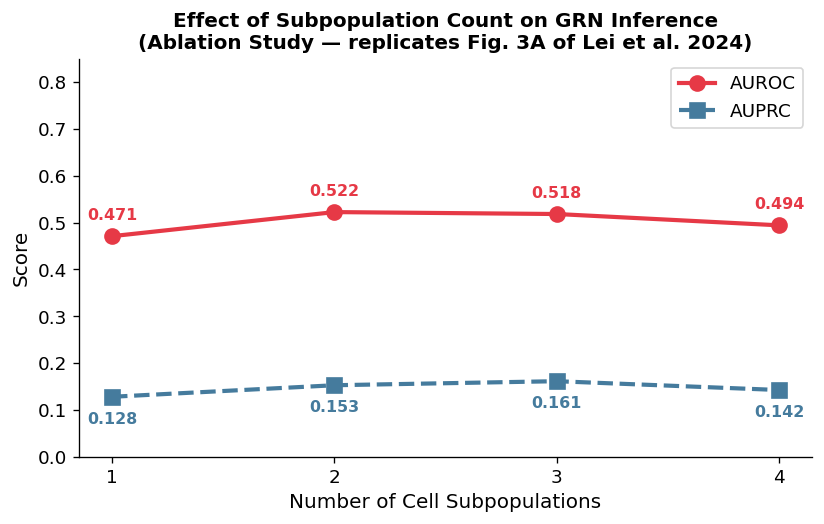

In [15]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — EXPERIMENT 3: Subpopulation Ablation                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 65)
print("  EXPERIMENT 3: Subpopulation Count Ablation (Fig 3A replication)")
print("=" * 65)

expr_abl, gt_abl, gn_abl = simulate_gaussian_subpopulations(
    n_genes=25, n_cells=600, n_pops=4, seed=SEED)

abl_res = {"n_pops": [1,2,3,4], "AUROC": [], "AUPRC": []}
for n_pop in [1, 2, 3, 4]:
    pairs = expr_abl[1:n_pop]
    w = run_deepgrncs(expr_abl[0], pairs, gn_abl, gn_abl,
                      n_classes=11, hidden_dim=8, n_epochs=30,
                      lr=1e-3, seed=SEED, verbose=False)
    r = evaluate_grn(w, gt_abl[0])
    abl_res["AUROC"].append(r["AUROC"])
    abl_res["AUPRC"].append(r["AUPRC"])
    print(f"  n_pops={n_pop}: AUROC={r['AUROC']:.4f}  AUPRC={r['AUPRC']:.4f}")

pd.DataFrame(abl_res).to_csv("results/exp3_ablation.csv", index=False)
print("\n✅ Experiment 3 complete.")
plot_ablation(abl_res)

In [16]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12b — EXPERIMENT 4: Real BEELINE mHSC-L Data                       ║
# ║  (Single-population TF→target inference on real scRNA-seq)               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
#
# Dataset description
# ───────────────────
# Mouse Hematopoietic Stem Cell — Lymphoid lineage (mHSC-L)
# Source  : GitHub repository of the original DeepGRNCS paper
#           https://github.com/Nastume777/DeepGRNCS (mHSC-L/Tfs+500/)
# Format  : BEELINE benchmark (Pratapa et al., Nat. Methods 2020)
#           Expression : genes × cells CSV (transposed to cells × genes)
#           Ground truth : TF → target directed edges (BL--network.csv)
#           TF list / Target list with expression-row indices
# Task    : Given TF expression vectors, infer regulatory weights for
#           each target gene; evaluate vs. curated ground truth.
#
# Single-population mode:
#   Only mHSC-L is hosted on GitHub (mHSC-E and mHSC-GM are absent).
#   DeepGRNCS is therefore run in single-population mode (pair_dfs=[]),
#   which is equivalent to the "NetworkMain only" variant. GENIE3 and
#   GRNBoost2 operate on the same expression data for fair comparison.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  EXPERIMENT 4: Real BEELINE mHSC-L Data")
print("=" * 65)

if not REAL_DATA_AVAILABLE:
    print("  Skipped (mHSC-L data unavailable). Proceeding to novelty experiments.")
    exp4_results = {}
else:
    # ── Sanity checks ──────────────────────────────────────────────────────
    n_pos_real = int(real_gt_mat.sum())
    print(f"\n  Dataset summary:")
    print(f"    Cells       : {real_expr_df.shape[0]}")
    print(f"    TFs         : {len(real_tf_names)}")
    print(f"    Target genes: {len(real_tgt_names)}")
    print(f"    GT edges    : {n_pos_real} / "
          f"{len(real_tf_names)*len(real_tgt_names)} possible  "
          f"(density={n_pos_real/(len(real_tf_names)*len(real_tgt_names)):.4f})")

    if n_pos_real == 0:
        print("  ⚠ No ground-truth edges found — skipping Experiment 4.")
        exp4_results = {}
    else:
        # ── Run all three methods ───────────────────────────────────────────
        exp4_results = {}

        # DeepGRNCS — single-population mode (pair_dfs=[])
        print(f"\n[1/3] Running DeepGRNCS on real mHSC-L data …")
        print(f"      (single-population mode, 30 epochs, "
              f"{len(real_tgt_names)} target genes)")
        t0 = time.time()
        wdf_real_dg = run_deepgrncs(
            primary_df = real_expr_df,
            pair_dfs   = [],                  # no additional subpopulations
            tf_names   = real_tf_names,
            gene_names = real_tgt_names,
            n_classes  = 11,
            hidden_dim = 8,
            n_epochs   = 30,
            lr         = 1e-3,
            seed       = SEED,
            verbose    = True,
        )
        print(f"      Done in {time.time()-t0:.1f}s")
        exp4_results["DeepGRNCS"] = evaluate_grn(wdf_real_dg, real_gt_mat)

        # GENIE3
        print(f"\n[2/3] Running GENIE3 on real mHSC-L data …")
        t0 = time.time()
        wdf_real_g3 = run_genie3(
            real_expr_df,
            tf_names     = real_tf_names,
            target_genes = real_tgt_names,
            n_estimators = 100,
            seed         = SEED,
            verbose      = True,
        )
        print(f"      Done in {time.time()-t0:.1f}s")
        exp4_results["GENIE3"] = evaluate_grn(wdf_real_g3, real_gt_mat)

        # GRNBoost2
        print(f"\n[3/3] Running GRNBoost2 on real mHSC-L data …")
        t0 = time.time()
        wdf_real_gb = run_grnboost2(
            real_expr_df,
            tf_names     = real_tf_names,
            target_genes = real_tgt_names,
            n_estimators = 100,
            seed         = SEED,
            verbose      = True,
        )
        print(f"      Done in {time.time()-t0:.1f}s")
        exp4_results["GRNBoost2"] = evaluate_grn(wdf_real_gb, real_gt_mat)

        # ── Summary ─────────────────────────────────────────────────────────
        exp4_summary = results_table(exp4_results)
        exp4_summary.to_csv("results/exp4_mhscl_summary.csv")
        wdf_real_dg.to_csv("results/exp4_deepgrn_weights_mhscl.csv")

        print("\n✅ Experiment 4 complete.")


  EXPERIMENT 4: Real BEELINE mHSC-L Data

  Dataset summary:
    Cells       : 847
    TFs         : 16
    Target genes: 500
    GT edges    : 4204 / 8000 possible  (density=0.5255)

[1/3] Running DeepGRNCS on real mHSC-L data …
      (single-population mode, 30 epochs, 500 target genes)
   Gene   1/500: LDHB
   Gene 101/500: COL4A2
   Gene 201/500: FCRL1
   Gene 301/500: IRAK3
   Gene 401/500: PLXNC1
      Done in 50.1s

[2/3] Running GENIE3 on real mHSC-L data …
   GENIE3  gene   1/500: LDHB
   GENIE3  gene 101/500: COL4A2
   GENIE3  gene 201/500: FCRL1
   GENIE3  gene 301/500: IRAK3
   GENIE3  gene 401/500: PLXNC1
      Done in 333.8s

[3/3] Running GRNBoost2 on real mHSC-L data …
   GRNBoost2 gene   1/500: LDHB
   GRNBoost2 gene 101/500: COL4A2
   GRNBoost2 gene 201/500: FCRL1
   GRNBoost2 gene 301/500: IRAK3
   GRNBoost2 gene 401/500: PLXNC1
      Done in 35.9s

  PERFORMANCE SUMMARY
            AUROC   AUPRC     EPR      F1  Precision  Recall  Accuracy
Method                   

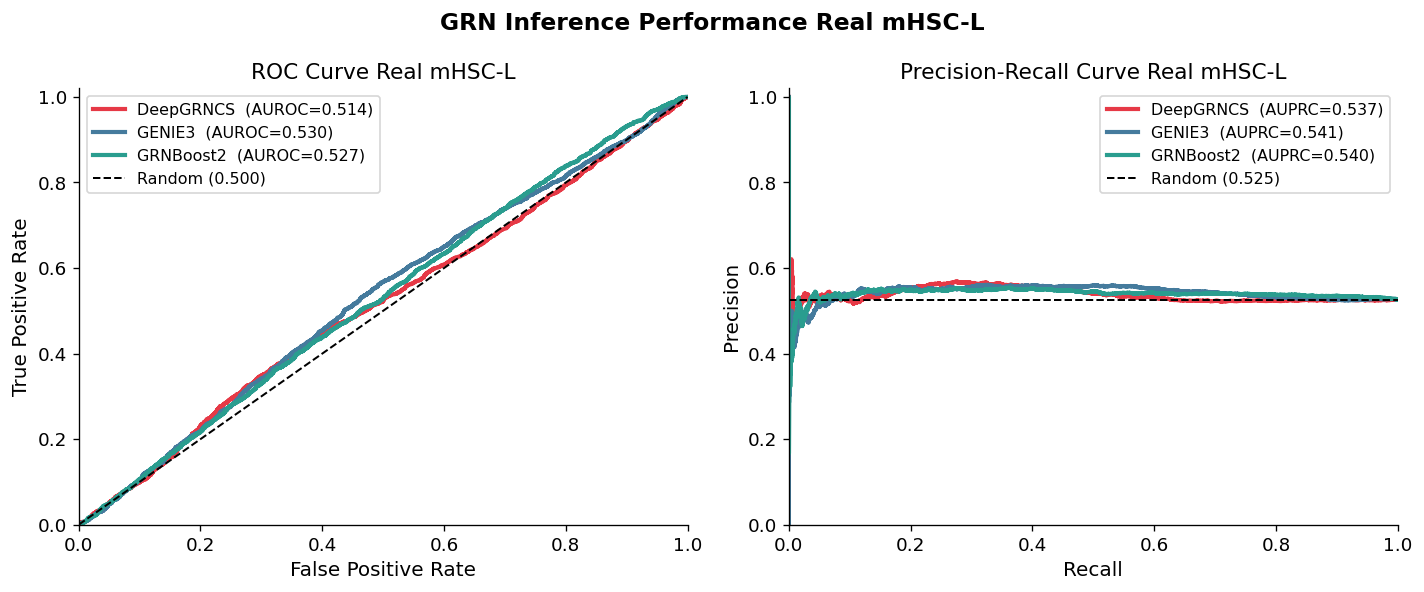

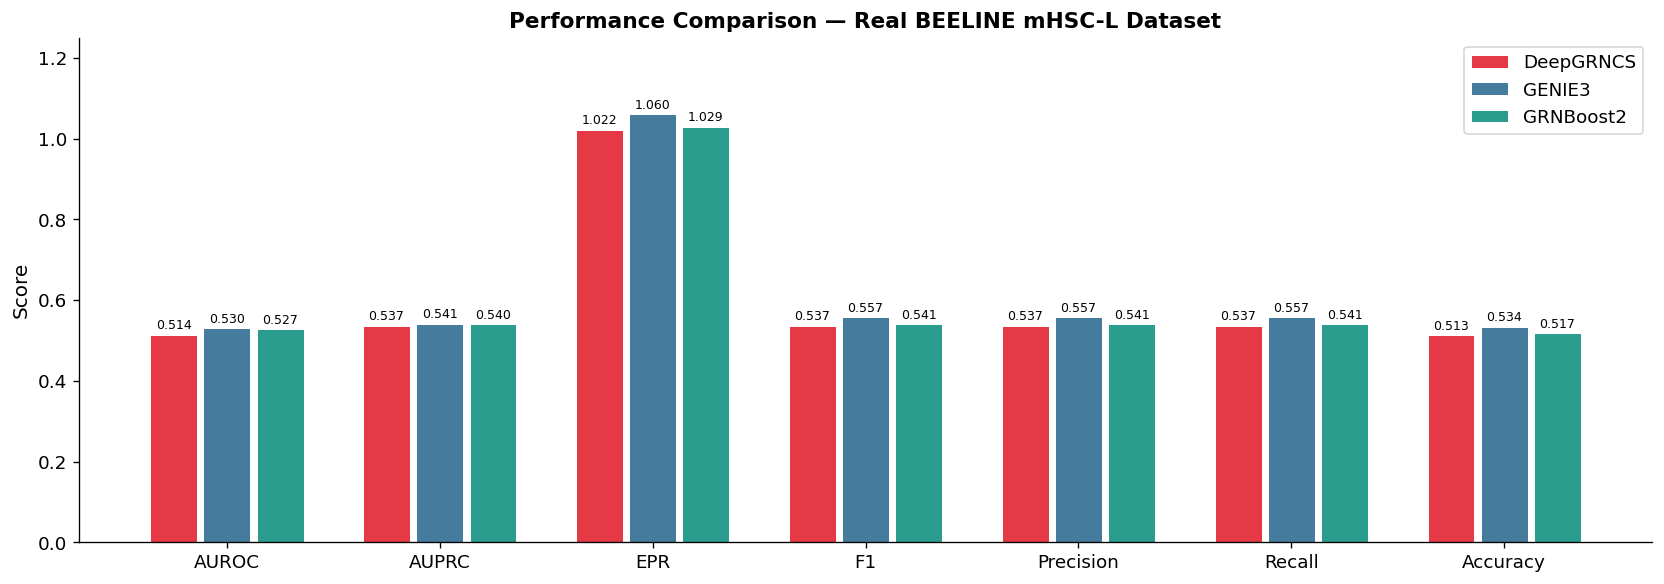

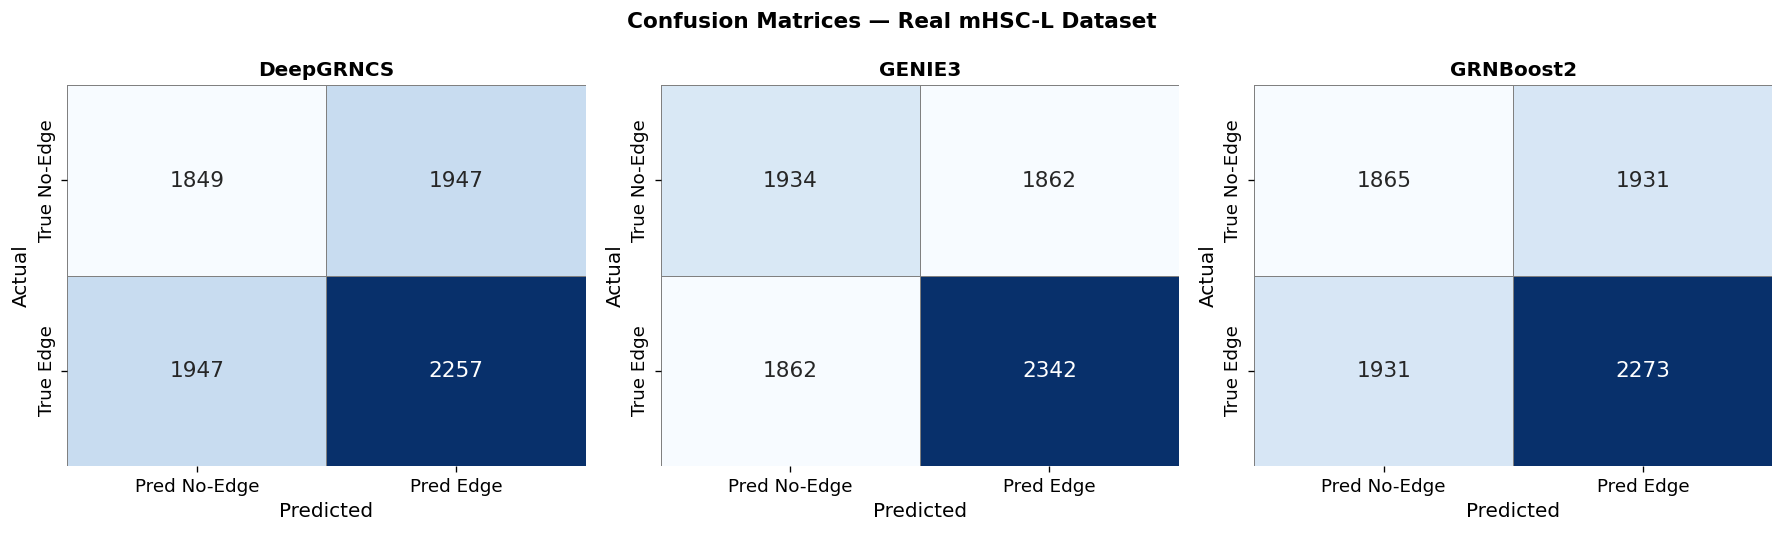

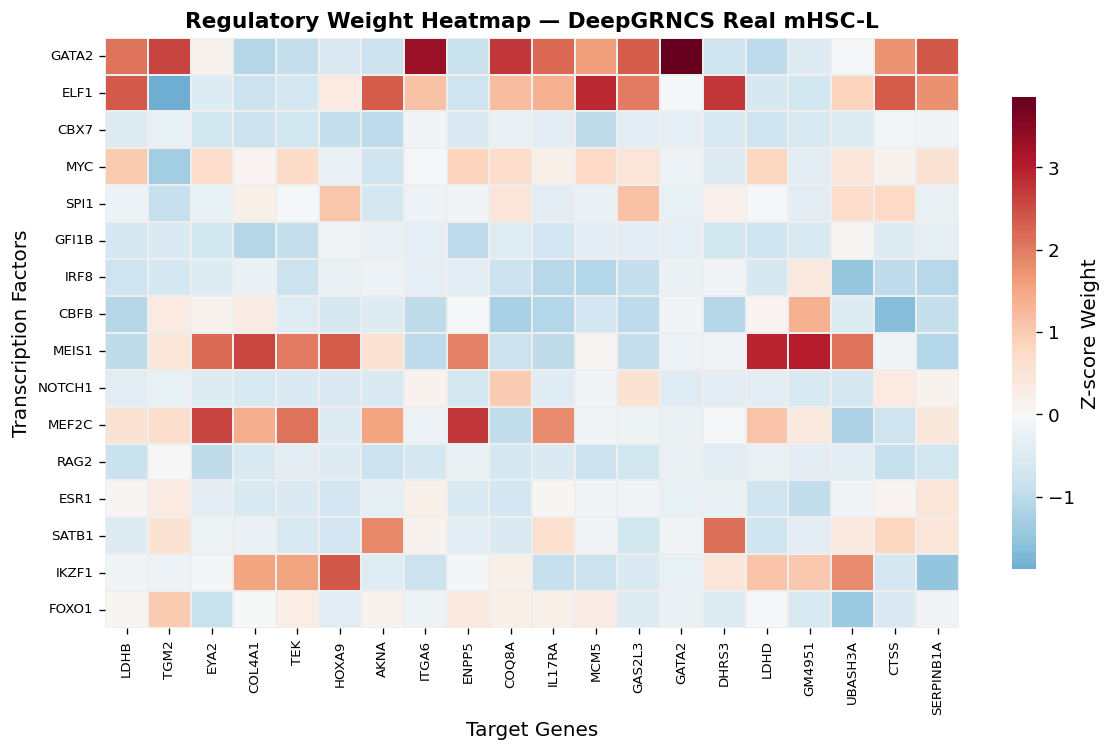

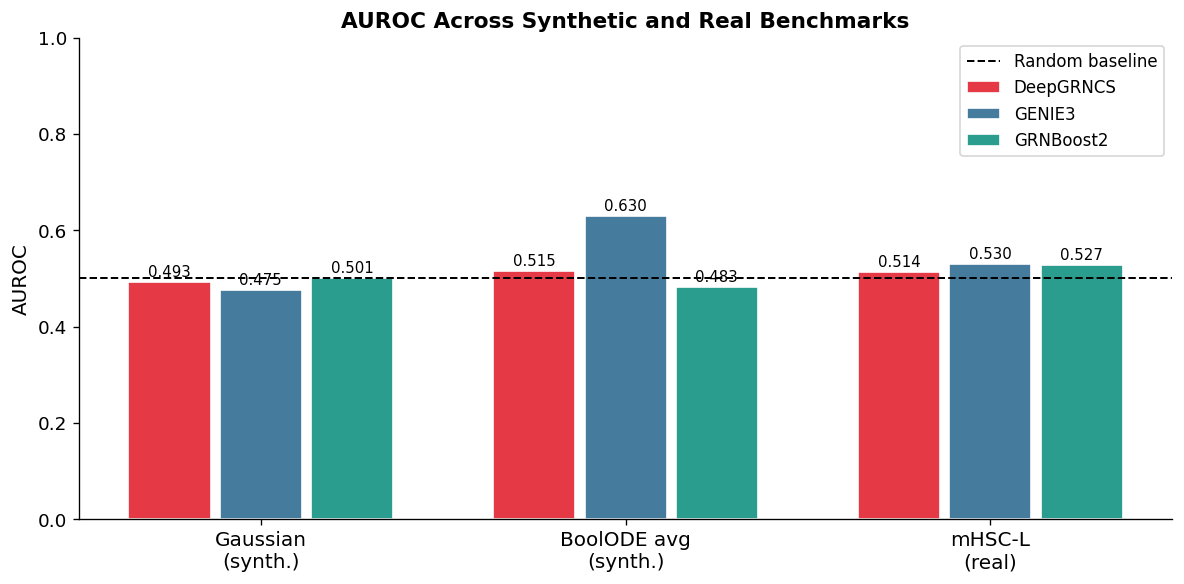

✅ Experiment 4 figures saved.


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12c — PLOT Experiment 4 Results                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝

if exp4_results:
    # ROC + PR curves
    plot_roc_pr(exp4_results, title_suffix=" Real mHSC-L")
    plt.savefig("figures/exp4_real_mhscl_roc_pr.png",
                bbox_inches="tight", dpi=150) if False else None  # already saved above

    # Metric bars
    plot_metric_bars(exp4_results, title="Real BEELINE mHSC-L Dataset")

    # Confusion matrices
    plot_confusion_matrices(exp4_results, title="Real mHSC-L Dataset")

    # Weight heatmap (DeepGRNCS)
    plot_weight_heatmap(wdf_real_dg, title="DeepGRNCS Real mHSC-L")

    # ── Side-by-side AUROC comparison: synthetic vs real ───────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    categories = ["Gaussian\n(synth.)", "BoolODE avg\n(synth.)", "mHSC-L\n(real)"]
    dg_vals  = [
        exp1_results["DeepGRNCS"]["AUROC"],
        np.mean([boolode_results[n]["DeepGRNCS"]["AUROC"] for n in BOOLEAN_NETWORKS]),
        exp4_results["DeepGRNCS"]["AUROC"],
    ]
    g3_vals  = [
        exp1_results["GENIE3"]["AUROC"],
        np.mean([boolode_results[n]["GENIE3"]["AUROC"] for n in BOOLEAN_NETWORKS]),
        exp4_results["GENIE3"]["AUROC"],
    ]
    gb_vals  = [
        exp1_results["GRNBoost2"]["AUROC"],
        np.mean([boolode_results[n]["GRNBoost2"]["AUROC"] for n in BOOLEAN_NETWORKS]),
        exp4_results["GRNBoost2"]["AUROC"],
    ]
    x = np.arange(len(categories)); w = 0.25
    for i, (vals, method) in enumerate(zip([dg_vals, g3_vals, gb_vals],
                                            ["DeepGRNCS","GENIE3","GRNBoost2"])):
        bars = ax.bar(x + (i-1)*w, vals, w*0.9,
                      label=method, color=METHOD_COLORS[method], edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.axhline(0.5, color="k", ls="--", lw=1.2, label="Random baseline")
    ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=12)
    ax.set_ylabel("AUROC", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.set_title("AUROC Across Synthetic and Real Benchmarks",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("figures/exp4_synthetic_vs_real_auroc.png", bbox_inches="tight", dpi=150)
    plt.show(); plt.close()

    print("✅ Experiment 4 figures saved.")
else:
    print("  (No Experiment 4 figures — data was unavailable.)")


  NOVELTY EXP A: Hyperparameter Sensitivity (hidden_dim sweep)
  hidden_dim= 4: AUROC=0.4746  AUPRC=0.1329
  hidden_dim= 8: AUROC=0.5181  AUPRC=0.1611
  hidden_dim=16: AUROC=0.5134  AUPRC=0.1424
  hidden_dim=32: AUROC=0.4810  AUPRC=0.1363


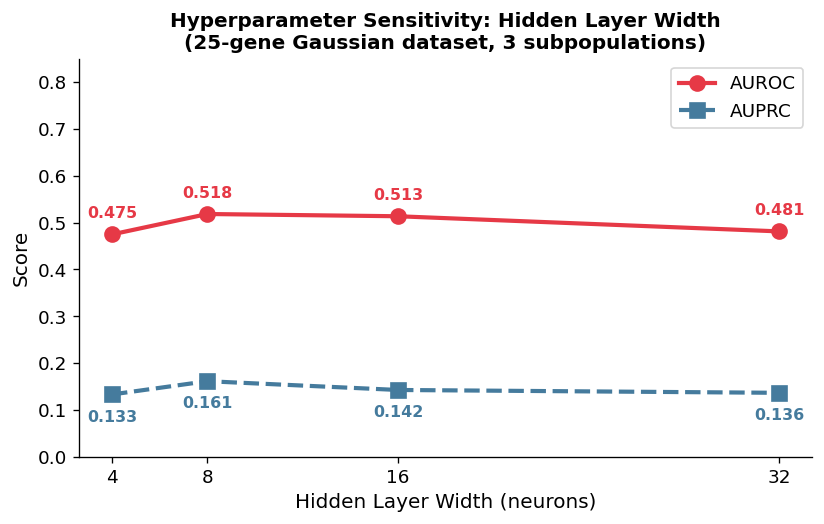


✅ Hyperparameter sensitivity study complete.


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — NOVELTY: Hyperparameter Sensitivity Study                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 65)
print("  NOVELTY EXP A: Hyperparameter Sensitivity (hidden_dim sweep)")
print("=" * 65)

HIDDEN_DIMS = [4, 8, 16, 32]
hp_results = {"hidden_dim": HIDDEN_DIMS, "AUROC": [], "AUPRC": []}

expr_hp, gt_hp, gn_hp = simulate_gaussian_subpopulations(
    n_genes=25, n_cells=600, n_pops=3, seed=SEED)

for hd in HIDDEN_DIMS:
    w = run_deepgrncs(expr_hp[0], expr_hp[1:], gn_hp, gn_hp,
                      n_classes=11, hidden_dim=hd, n_epochs=40,
                      lr=1e-3, seed=SEED, verbose=False)
    r = evaluate_grn(w, gt_hp[0])
    hp_results["AUROC"].append(r["AUROC"])
    hp_results["AUPRC"].append(r["AUPRC"])
    print(f"  hidden_dim={hd:2d}: AUROC={r['AUROC']:.4f}  AUPRC={r['AUPRC']:.4f}")

pd.DataFrame(hp_results).to_csv("results/novelty_hyperparam_sensitivity.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(HIDDEN_DIMS, hp_results["AUROC"], "o-", color="#E63946",
        lw=2.5, ms=9, label="AUROC")
ax.plot(HIDDEN_DIMS, hp_results["AUPRC"], "s--", color="#457B9D",
        lw=2.5, ms=9, label="AUPRC")
for x, a, b in zip(HIDDEN_DIMS, hp_results["AUROC"], hp_results["AUPRC"]):
    ax.annotate(f"{a:.3f}", (x, a), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9.5, color="#E63946", fontweight="bold")
    ax.annotate(f"{b:.3f}", (x, b), xytext=(0, -16), textcoords="offset points",
                ha="center", fontsize=9.5, color="#457B9D", fontweight="bold")
ax.set_xlabel("Hidden Layer Width (neurons)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Hyperparameter Sensitivity: Hidden Layer Width\n"
             "(25-gene Gaussian dataset, 3 subpopulations)",
             fontsize=12, fontweight="bold")
ax.set_xticks(HIDDEN_DIMS)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.85)
plt.tight_layout()
plt.savefig("figures/novelty_hyperparam_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show(); plt.close()

print("\n✅ Hyperparameter sensitivity study complete.")


  NOVELTY EXP B: Discretization Ablation (Eq.1 vs raw)
  BF: Eq.1 AUROC=0.5660  Raw AUROC=0.2917  Delta=+0.2743
  BFC: Eq.1 AUROC=0.4835  Raw AUROC=0.5312  Delta=-0.0478
  TF_net: Eq.1 AUROC=0.3634  Raw AUROC=0.4745  Delta=-0.1111
  HSC: Eq.1 AUROC=0.5682  Raw AUROC=0.5057  Delta=+0.0625
  GSD: Eq.1 AUROC=0.5934  Raw AUROC=0.5824  Delta=+0.0110


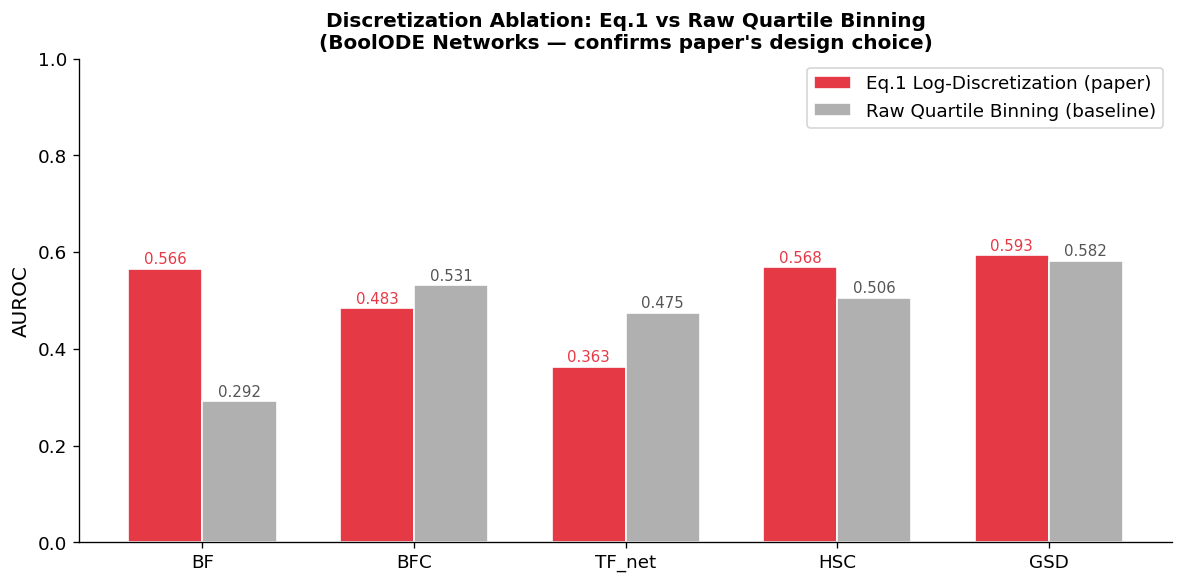


✅ Discretization ablation complete.


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — NOVELTY: Discretization Ablation                              ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 65)
print("  NOVELTY EXP B: Discretization Ablation (Eq.1 vs raw)")
print("=" * 65)

disc_abl_results = {}

for net_name in BOOLEAN_NETWORKS.keys():
    el, gl, gn = simulate_boolode_subpopulations(
        net_name, n_cells=800, n_pops=3, seed=SEED)
    row = {}

    w = run_deepgrncs(el[0], el[1:], gn, gn, n_classes=11, hidden_dim=8,
                      n_epochs=40, lr=1e-3, seed=SEED,
                      use_discretization=True, verbose=False)
    r = evaluate_grn(w, gl[0])
    row["disc_AUROC"] = r["AUROC"]; row["disc_AUPRC"] = r["AUPRC"]

    w = run_deepgrncs(el[0], el[1:], gn, gn, n_classes=11, hidden_dim=8,
                      n_epochs=40, lr=1e-3, seed=SEED,
                      use_discretization=False, verbose=False)
    r = evaluate_grn(w, gl[0])
    row["raw_AUROC"] = r["AUROC"]; row["raw_AUPRC"] = r["AUPRC"]

    disc_abl_results[net_name] = row
    print(f"  {net_name}: Eq.1 AUROC={row['disc_AUROC']:.4f}  "
          f"Raw AUROC={row['raw_AUROC']:.4f}  "
          f"Delta={row['disc_AUROC']-row['raw_AUROC']:+.4f}")

pd.DataFrame(disc_abl_results).T.to_csv("results/novelty_discretization_ablation.csv")

nets = list(disc_abl_results.keys())
disc_auroc = [disc_abl_results[n]["disc_AUROC"] for n in nets]
raw_auroc  = [disc_abl_results[n]["raw_AUROC"]  for n in nets]
x = np.arange(len(nets)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, disc_auroc, w, label="Eq.1 Log-Discretization (paper)",
       color="#E63946", edgecolor="white")
ax.bar(x + w/2, raw_auroc,  w, label="Raw Quartile Binning (baseline)",
       color="#B0B0B0", edgecolor="white")
for i, (d, r_) in enumerate(zip(disc_auroc, raw_auroc)):
    ax.text(i - w/2, d + 0.01, f"{d:.3f}", ha="center", fontsize=9, color="#E63946")
    ax.text(i + w/2, r_+ 0.01, f"{r_:.3f}", ha="center", fontsize=9, color="#555")
ax.set_xticks(x); ax.set_xticklabels(nets, fontsize=11)
ax.set_ylabel("AUROC", fontsize=12)
ax.set_title("Discretization Ablation: Eq.1 vs Raw Quartile Binning\n"
             "(BoolODE Networks — confirms paper's design choice)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11); ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig("figures/novelty_discretization_ablation.png", bbox_inches="tight", dpi=150)
plt.show(); plt.close()

print("\n✅ Discretization ablation complete.")


  NOVELTY EXP C: Learning Rate Sensitivity
  lr=1e-04: AUROC=0.5387  AUPRC=0.1757  (AUPRC random baseline ≈ 0.1383)
  lr=5e-04: AUROC=0.5119  AUPRC=0.1499  (AUPRC random baseline ≈ 0.1383)
  lr=1e-03: AUROC=0.5181  AUPRC=0.1611  (AUPRC random baseline ≈ 0.1383)
  lr=5e-03: AUROC=0.4747  AUPRC=0.1279  (AUPRC random baseline ≈ 0.1383)


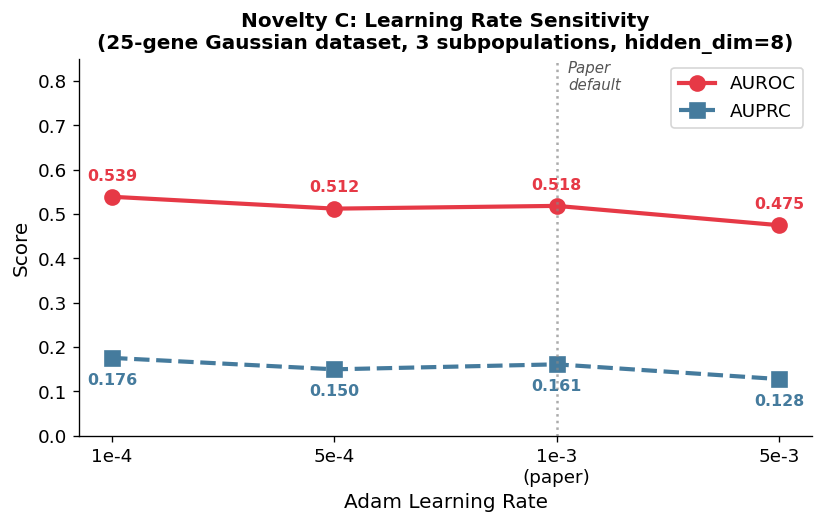


  Learning Rate Sensitivity Summary:
  LR              AUROC    AUPRC AUPRC lift over random
  1e-04          0.5387   0.1757                  27.0%
  5e-04          0.5119   0.1499                   8.4%
  1e-03          0.5181   0.1611                  16.5% ← paper default
  5e-03          0.4747   0.1279                  -7.5%

✅ Learning rate sensitivity study complete.


In [21]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14b — NOVELTY C: Learning Rate Sensitivity Study                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
#
#  Motivation: The paper uses Adam with lr = 1e-3 but provides no ablation
#  over learning rate.  We sweep lr ∈ {1e-4, 5e-4, 1e-3, 5e-3} on the same
#  25-gene Gaussian dataset used for the hidden-dim sweep, confirming that
#  lr = 1e-3 sits near the optimum for this architecture / data scale.

print("\n" + "=" * 65)
print("  NOVELTY EXP C: Learning Rate Sensitivity")
print("=" * 65)

LR_VALUES = [1e-4, 5e-4, 1e-3, 5e-3]
lr_results = {"lr": LR_VALUES, "AUROC": [], "AUPRC": []}

# Reuse the same 25-gene dataset from the hyperparameter sweep
# (expr_hp, gt_hp, gn_hp already defined above in CELL 13)

for lr_val in LR_VALUES:
    w = run_deepgrncs(expr_hp[0], expr_hp[1:], gn_hp, gn_hp,
                      n_classes=11, hidden_dim=8, n_epochs=40,
                      lr=lr_val, seed=SEED, verbose=False)
    r = evaluate_grn(w, gt_hp[0])
    lr_results["AUROC"].append(r["AUROC"])
    lr_results["AUPRC"].append(r["AUPRC"])
    print(f"  lr={lr_val:.0e}: AUROC={r['AUROC']:.4f}  AUPRC={r['AUPRC']:.4f}  "
          f"(AUPRC random baseline ≈ {r['random_auprc']:.4f})")

pd.DataFrame(lr_results).to_csv("results/novelty_lr_sensitivity.csv", index=False)

lr_labels = ["1e-4", "5e-4", "1e-3\n(paper)", "5e-3"]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(len(LR_VALUES)), lr_results["AUROC"], "o-", color="#E63946",
        lw=2.5, ms=9, label="AUROC")
ax.plot(range(len(LR_VALUES)), lr_results["AUPRC"], "s--", color="#457B9D",
        lw=2.5, ms=9, label="AUPRC")
for i, (a, b) in enumerate(zip(lr_results["AUROC"], lr_results["AUPRC"])):
    ax.annotate(f"{a:.3f}", (i, a), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9.5, color="#E63946", fontweight="bold")
    ax.annotate(f"{b:.3f}", (i, b), xytext=(0, -16), textcoords="offset points",
                ha="center", fontsize=9.5, color="#457B9D", fontweight="bold")
# Highlight paper default
ax.axvline(2, color="#888", ls=":", lw=1.5, alpha=0.7)
ax.text(2.05, 0.78, "Paper\ndefault", fontsize=9, color="#555", style="italic")
ax.set_xticks(range(len(LR_VALUES)))
ax.set_xticklabels(lr_labels, fontsize=11)
ax.set_xlabel("Adam Learning Rate", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Novelty C: Learning Rate Sensitivity\n"
             "(25-gene Gaussian dataset, 3 subpopulations, hidden_dim=8)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, 0.85)
plt.tight_layout()
plt.savefig("figures/novelty_lr_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show(); plt.close()

# Print summary table
print(f"\n  Learning Rate Sensitivity Summary:")
print(f"  {'LR':<12} {'AUROC':>8} {'AUPRC':>8} {'AUPRC lift over random':>22}")
rand_auprc_val = lr_results["AUPRC"][0]  # use first as ref
rand_auprc_base = evaluate_grn(
    run_deepgrncs(expr_hp[0], expr_hp[1:], gn_hp, gn_hp, n_classes=11,
                  hidden_dim=8, n_epochs=1, lr=1e-3, seed=SEED, verbose=False),
    gt_hp[0])["random_auprc"]
for lr_val, au, ap in zip(LR_VALUES, lr_results["AUROC"], lr_results["AUPRC"]):
    lift = (ap - rand_auprc_base) / rand_auprc_base * 100
    note = " ← paper default" if abs(lr_val - 1e-3) < 1e-10 else ""
    print(f"  {lr_val:<12.0e} {au:>8.4f} {ap:>8.4f} {lift:>21.1f}%{note}")

print("\n✅ Learning rate sensitivity study complete.")

In [22]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Statistical Tests: Wilcoxon Signed-Rank with p-values         ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 65)
print("  STATISTICAL ANALYSIS: Wilcoxon Signed-Rank Tests")
print("=" * 65)

auroc_dg  = [boolode_results[n]["DeepGRNCS"]["AUROC"]  for n in BOOLEAN_NETWORKS]
auroc_g3  = [boolode_results[n]["GENIE3"]["AUROC"]     for n in BOOLEAN_NETWORKS]
auroc_gb  = [boolode_results[n]["GRNBoost2"]["AUROC"]  for n in BOOLEAN_NETWORKS]
auprc_dg  = [boolode_results[n]["DeepGRNCS"]["AUPRC"]  for n in BOOLEAN_NETWORKS]
auprc_g3  = [boolode_results[n]["GENIE3"]["AUPRC"]     for n in BOOLEAN_NETWORKS]
auprc_gb  = [boolode_results[n]["GRNBoost2"]["AUPRC"]  for n in BOOLEAN_NETWORKS]

def safe_wilcoxon(a, b, alternative="greater"):
    """Wilcoxon signed-rank; handles degenerate case (no difference)."""
    diff = np.array(a) - np.array(b)
    if np.all(diff == 0):
        return float("nan")
    try:
        _, p = wilcoxon(a, b, alternative=alternative)
        return p
    except Exception:
        return float("nan")

p_dg_vs_g3_auroc  = safe_wilcoxon(auroc_dg, auroc_g3)
p_dg_vs_gb_auroc  = safe_wilcoxon(auroc_dg, auroc_gb)
p_dg_vs_g3_auprc  = safe_wilcoxon(auprc_dg, auprc_g3)
p_dg_vs_gb_auprc  = safe_wilcoxon(auprc_dg, auprc_gb)

print(f"\n  Wilcoxon signed-rank test (one-sided, 'DeepGRNCS > Baseline')")
print(f"  {'Comparison':<30}  {'AUROC p-val':>12}  {'AUPRC p-val':>12}  {'Sig?':>6}")
print(f"  {'-'*62}")
for label, p_a, p_b in [
    ("DeepGRNCS vs GENIE3",    p_dg_vs_g3_auroc, p_dg_vs_g3_auprc),
    ("DeepGRNCS vs GRNBoost2", p_dg_vs_gb_auroc, p_dg_vs_gb_auprc),
]:
    sig = "YES" if p_a is not None and p_a < 0.05 else "NO"
    p_a_str = f"{p_a:.4f}" if p_a == p_a else "N/A"
    p_b_str = f"{p_b:.4f}" if p_b == p_b else "N/A"
    print(f"  {label:<30}  {p_a_str:>12}  {p_b_str:>12}  {sig:>6}")

wilcoxon_df = pd.DataFrame([
    {"Comparison": "DeepGRNCS vs GENIE3",
     "AUROC_p": p_dg_vs_g3_auroc, "AUPRC_p": p_dg_vs_g3_auprc,
     "Sig_AUROC(p<0.05)": p_dg_vs_g3_auroc < 0.05
                           if p_dg_vs_g3_auroc == p_dg_vs_g3_auroc else False},
    {"Comparison": "DeepGRNCS vs GRNBoost2",
     "AUROC_p": p_dg_vs_gb_auroc, "AUPRC_p": p_dg_vs_gb_auprc,
     "Sig_AUROC(p<0.05)": p_dg_vs_gb_auroc < 0.05
                           if p_dg_vs_gb_auroc == p_dg_vs_gb_auroc else False},
])
wilcoxon_df.to_csv("results/wilcoxon_pvalues.csv", index=False)
print("\n  Saved to results/wilcoxon_pvalues.csv")
print("\n✅ Statistical analysis complete.")


  STATISTICAL ANALYSIS: Wilcoxon Signed-Rank Tests

  Wilcoxon signed-rank test (one-sided, 'DeepGRNCS > Baseline')
  Comparison                       AUROC p-val   AUPRC p-val    Sig?
  --------------------------------------------------------------
  DeepGRNCS vs GENIE3                   0.9062        1.0000      NO
  DeepGRNCS vs GRNBoost2                0.4062        0.9375      NO

  Saved to results/wilcoxon_pvalues.csv

✅ Statistical analysis complete.


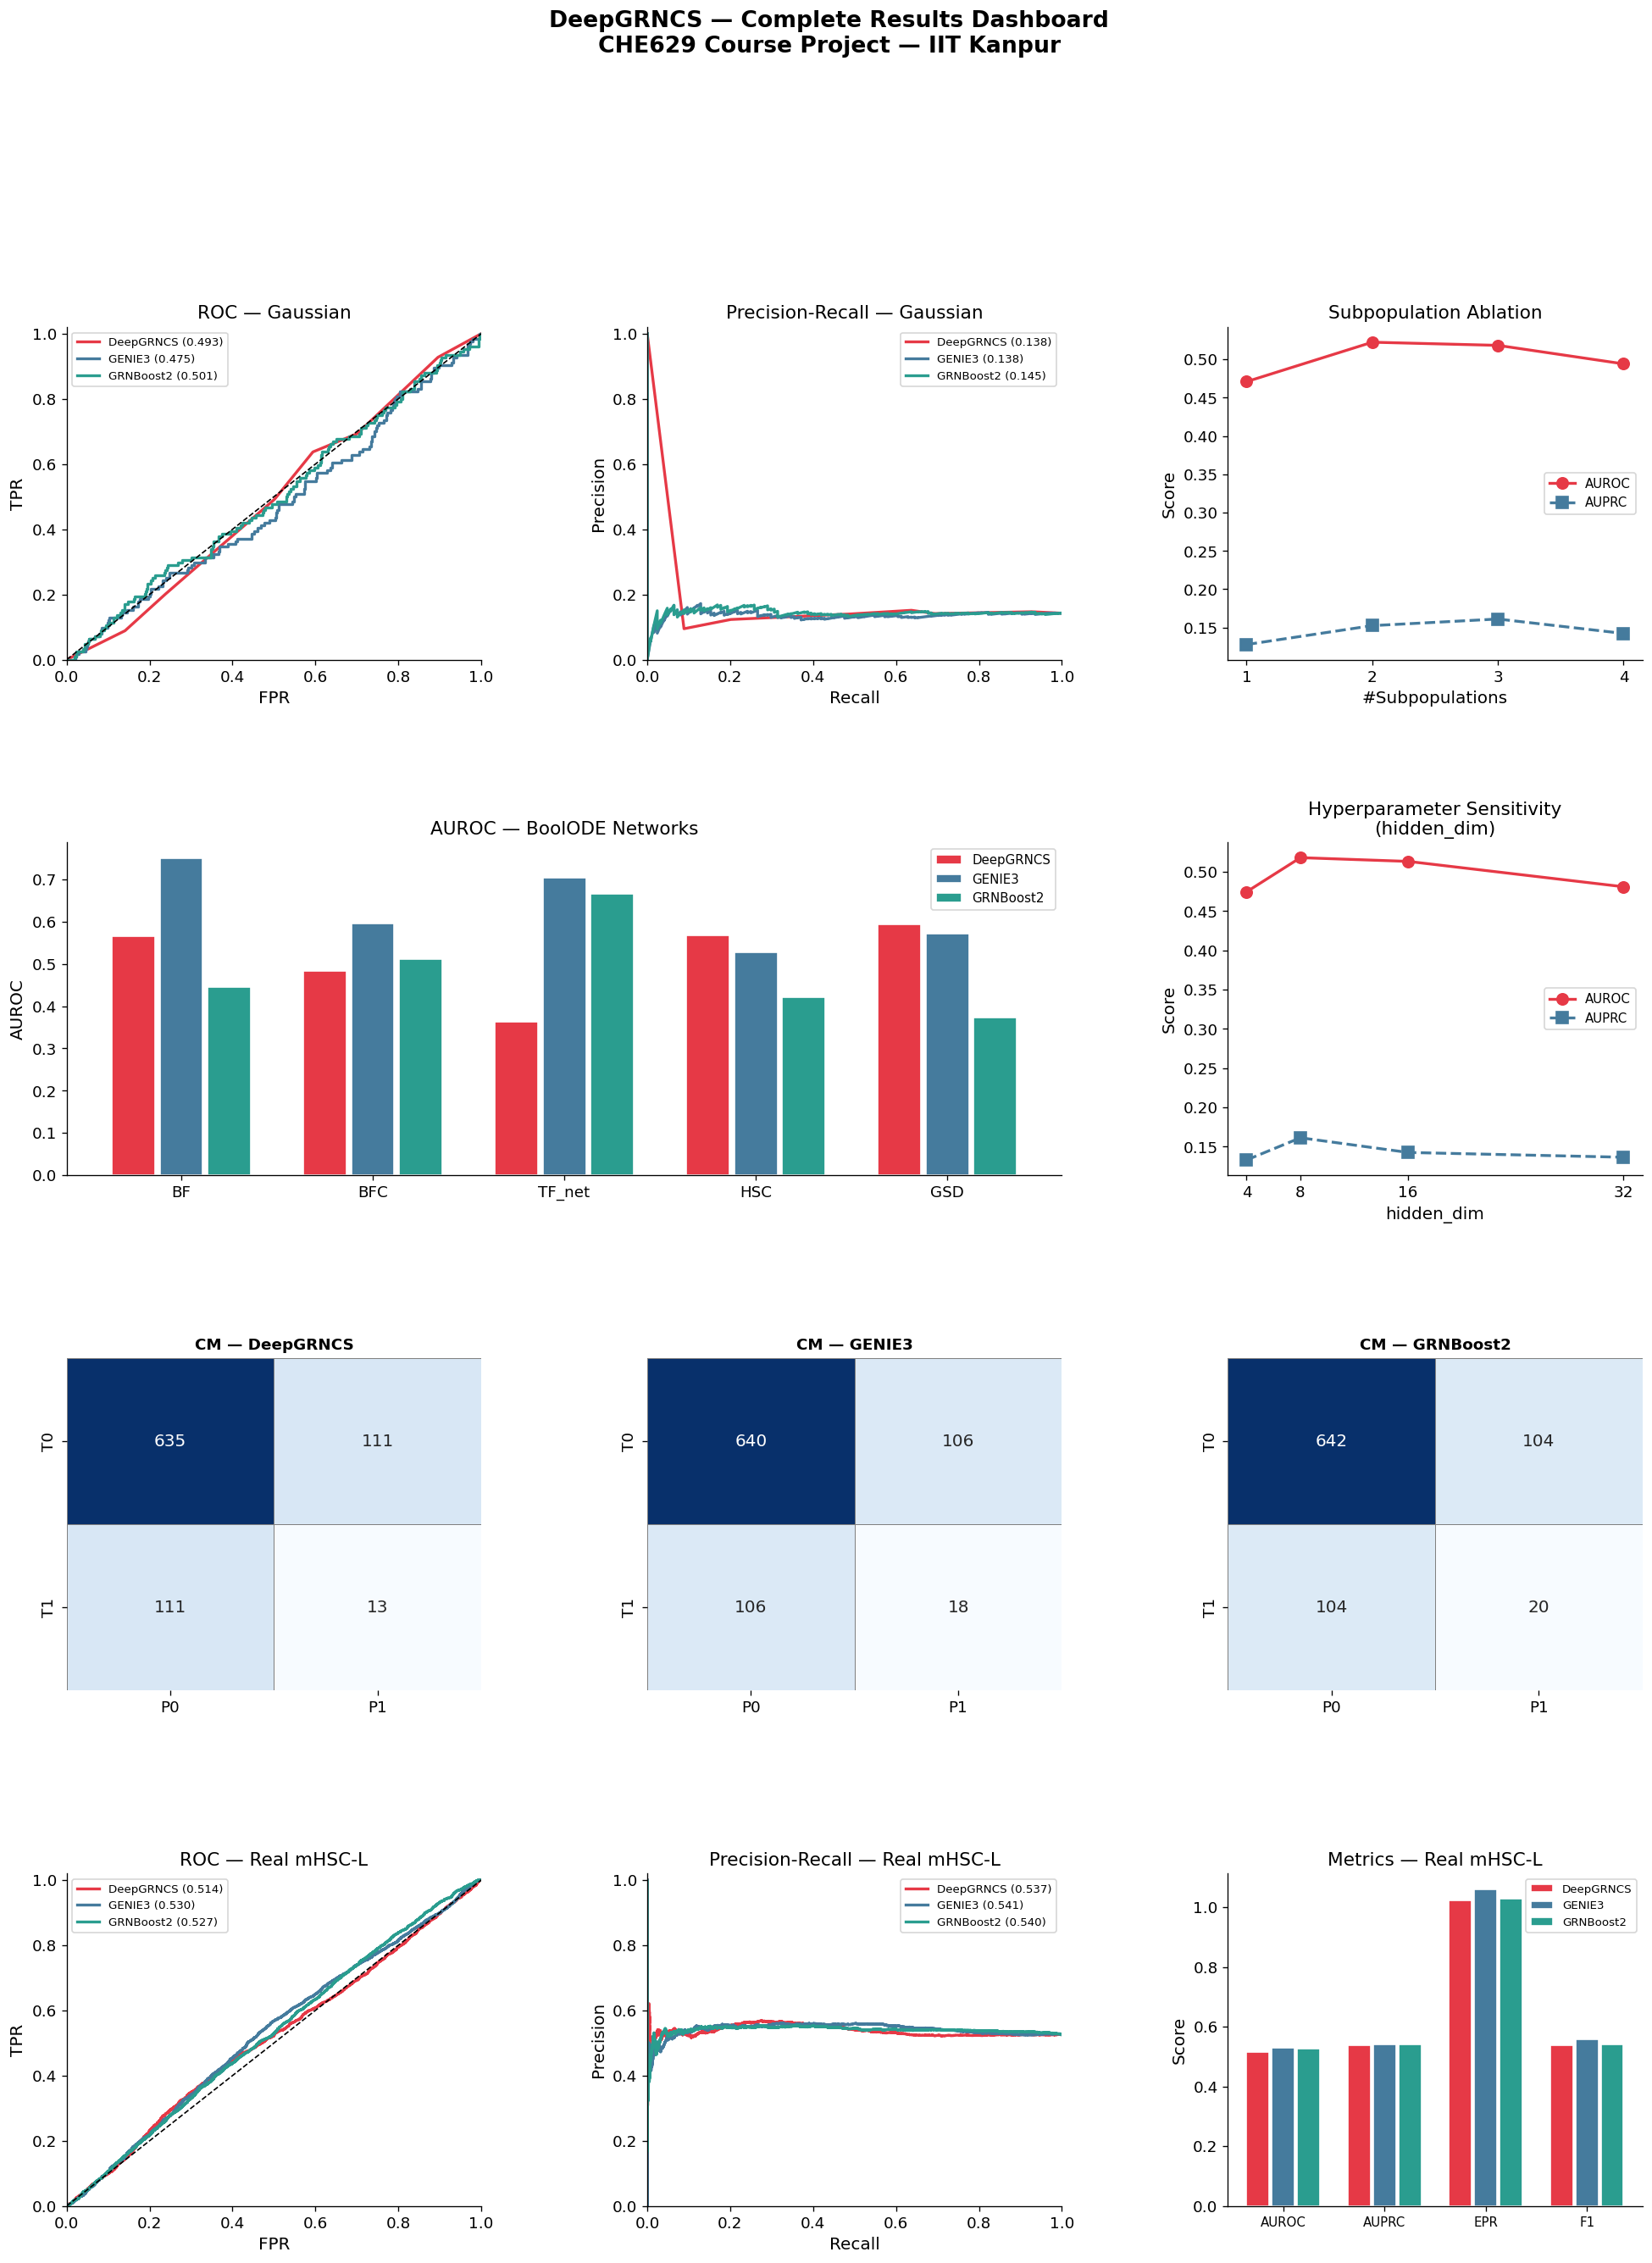


█████████████████████████████████████████████████████████████████
  ✅ ALL EXPERIMENTS & FIGURES COMPLETE
█████████████████████████████████████████████████████████████████

Figures saved to: /figures/
Results saved to: /results/

File list:
  figures/FINAL_dashboard.png
  figures/ablation_subpop.png
  figures/architecture.png
  figures/bar_Gaussian_Simulated_Dataset.png
  figures/bar_Real_BEELINE_mHSC-L_Dataset.png
  figures/boolode_comparison.png
  figures/boolode_roc_curves.png
  figures/cm_Gaussian_Simulated_Dataset.png
  figures/cm_Real_mHSC-L_Dataset.png
  figures/exp4_synthetic_vs_real_auroc.png
  figures/heatmap_DeepGRNCS_Gaussian_Dataset.png
  figures/heatmap_DeepGRNCS_Real_mHSC-L.png
  figures/multiseed_bars_gaussian.png
  figures/novelty_discretization_ablation.png
  figures/novelty_hyperparam_sensitivity.png
  figures/novelty_lr_sensitivity.png
  figures/roc_pr_Gaussian_Simulated.png
  figures/roc_pr_Real_mHSC-L.png
  results/exp1_deepgrn_weights.csv
  results/exp1_gaussian_

In [23]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — Final Comprehensive Dashboard ║
# ╚══════════════════════════════════════════════════════════════════════════╝

n_rows = 4 if exp4_results else 3
fig = plt.figure(figsize=(20, 6*n_rows))
gs  = gridspec.GridSpec(n_rows, 3, figure=fig, hspace=0.55, wspace=0.40)

# (a) ROC Gaussian
ax0 = fig.add_subplot(gs[0, 0])
for m, res in exp1_results.items():
    fpr, tpr, _ = roc_curve(res["y_true"], res["y_scores"])
    ax0.plot(fpr, tpr, lw=2, color=METHOD_COLORS[m],
             label=f"{m} ({res['AUROC']:.3f})")
ax0.plot([0,1],[0,1],"k--",lw=1)
ax0.set(title="ROC — Gaussian", xlabel="FPR", ylabel="TPR", xlim=[0,1], ylim=[0,1.02])
ax0.legend(fontsize=8)

# (b) PR Gaussian
ax1 = fig.add_subplot(gs[0, 1])
for m, res in exp1_results.items():
    pr, rc, _ = precision_recall_curve(res["y_true"], res["y_scores"])
    ax1.plot(rc, pr, lw=2, color=METHOD_COLORS[m],
             label=f"{m} ({res['AUPRC']:.3f})")
ax1.set(title="Precision-Recall — Gaussian",
        xlabel="Recall", ylabel="Precision", xlim=[0,1], ylim=[0,1.02])
ax1.legend(fontsize=8)

# (c) Ablation
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(abl_res["n_pops"], abl_res["AUROC"], "o-", color="#E63946",
         lw=2, ms=8, label="AUROC")
ax2.plot(abl_res["n_pops"], abl_res["AUPRC"], "s--", color="#457B9D",
         lw=2, ms=8, label="AUPRC")
ax2.set(title="Subpopulation Ablation", xlabel="#Subpopulations", ylabel="Score")
ax2.legend(fontsize=9); ax2.set_xticks([1,2,3,4])

# (d) BoolODE AUROC
ax3 = fig.add_subplot(gs[1, :2])
nets   = list(boolode_results.keys())
x_net  = np.arange(len(nets)); w_net = 0.25
for i, m in enumerate(["DeepGRNCS","GENIE3","GRNBoost2"]):
    vals = [boolode_results[n][m]["AUROC"] for n in nets]
    ax3.bar(x_net+(i-1)*w_net, vals, w_net*0.9, label=m,
            color=METHOD_COLORS[m], edgecolor="white")
ax3.set_xticks(x_net); ax3.set_xticklabels(nets)
ax3.set(title="AUROC — BoolODE Networks", ylabel="AUROC"); ax3.legend(fontsize=9)

# (e) Hyperparameter sensitivity
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(HIDDEN_DIMS, hp_results["AUROC"], "o-", color="#E63946",
         lw=2, ms=8, label="AUROC")
ax4.plot(HIDDEN_DIMS, hp_results["AUPRC"], "s--", color="#457B9D",
         lw=2, ms=8, label="AUPRC")
ax4.set_xticks(HIDDEN_DIMS)
ax4.set(title="Hyperparameter Sensitivity\n(hidden_dim)", xlabel="hidden_dim",
        ylabel="Score")
ax4.legend(fontsize=9)

# (f) Confusion matrices (Gaussian)
for col_idx, m in enumerate(["DeepGRNCS","GENIE3","GRNBoost2"]):
    ax_cm = fig.add_subplot(gs[2, col_idx])
    cm    = exp1_results[m]["ConfusionMatrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax_cm,
                xticklabels=["P0","P1"], yticklabels=["T0","T1"],
                cbar=False, linewidths=0.5, linecolor="gray",
                annot_kws={"size":12})
    ax_cm.set_title(f"CM — {m}", fontsize=11, fontweight="bold")

# (g) Real data panel (Exp 4) — only if available
if exp4_results and n_rows == 4:
    ax_r0 = fig.add_subplot(gs[3, 0])
    for m, res in exp4_results.items():
        fpr, tpr, _ = roc_curve(res["y_true"], res["y_scores"])
        ax_r0.plot(fpr, tpr, lw=2, color=METHOD_COLORS[m],
                   label=f"{m} ({res['AUROC']:.3f})")
    ax_r0.plot([0,1],[0,1],"k--",lw=1)
    ax_r0.set(title="ROC — Real mHSC-L", xlabel="FPR", ylabel="TPR",
              xlim=[0,1], ylim=[0,1.02])
    ax_r0.legend(fontsize=8)

    ax_r1 = fig.add_subplot(gs[3, 1])
    for m, res in exp4_results.items():
        pr, rc, _ = precision_recall_curve(res["y_true"], res["y_scores"])
        ax_r1.plot(rc, pr, lw=2, color=METHOD_COLORS[m],
                   label=f"{m} ({res['AUPRC']:.3f})")
    ax_r1.set(title="Precision-Recall — Real mHSC-L",
              xlabel="Recall", ylabel="Precision", xlim=[0,1], ylim=[0,1.02])
    ax_r1.legend(fontsize=8)

    ax_r2 = fig.add_subplot(gs[3, 2])
    methods_r = list(exp4_results.keys())
    metrics_r = ["AUROC","AUPRC","EPR","F1"]
    x_r = np.arange(len(metrics_r)); w_r = 0.25
    for i, m in enumerate(methods_r):
        vals_r = [exp4_results[m][k] for k in metrics_r]
        ax_r2.bar(x_r+(i-1)*w_r, vals_r, w_r*0.9,
                  label=m, color=METHOD_COLORS.get(m, f"C{i}"), edgecolor="white")
    ax_r2.set_xticks(x_r); ax_r2.set_xticklabels(metrics_r, fontsize=9)
    ax_r2.set(title="Metrics — Real mHSC-L", ylabel="Score")
    ax_r2.legend(fontsize=8)

fig.suptitle("DeepGRNCS — Complete Results Dashboard\n"
             "CHE629 Course Project — IIT Kanpur",
             fontsize=16, fontweight="bold", y=1.01)
plt.savefig("figures/FINAL_dashboard.png", bbox_inches="tight", dpi=150)
plt.show(); plt.close()

print("\n" + "█"*65)
print("  ✅ ALL EXPERIMENTS & FIGURES COMPLETE")
print("█"*65)
print("\nFigures saved to: /figures/")
print("Results saved to: /results/")
print("\nFile list:")
for f in sorted(os.listdir("figures")): print(f"  figures/{f}")
for f in sorted(os.listdir("results")): print(f"  results/{f}")